In [1]:
import re
import os
import sys
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from nltk import pos_tag
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS

import gensim
from gensim import corpora
from gensim.models import CoherenceModel

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

try:
    import torch
except Exception:
    torch = None


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)

    for p in [start.resolve()] + list(start.resolve().parents):
        if (p / "csvs").exists() and (p / "markdown").exists():
            return p

    return start.resolve()


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


try:
    import scripts.text_mining_utils as tmu
except ImportError:
    tmu = None
    print("Warning: scripts.text_mining_utils not found. Continuing without it.")


# ==========================================
# Folder settings
# ==========================================

CSVS_CHUNKED = PROJECT_ROOT / "csvs" / "chunked"
CHUNKS_ALL = CSVS_CHUNKED / "chunks_all.csv"

PIPELINE_DIR = (
    PROJECT_ROOT
    / "progress"
    / "topic_modelling"
    / "nmf"
    / "policy"
)

OUT_DIR = PIPELINE_DIR / "output"
GLOBAL_OUT_DIR = OUT_DIR / "global"
COUNTRY_OUT_DIR = OUT_DIR / "per_country"

IMG_DIR = PIPELINE_DIR / "img"
GLOBAL_IMG_DIR = IMG_DIR / "global"
COUNTRY_IMG_DIR = IMG_DIR / "per_country"

for folder in [
    OUT_DIR,
    GLOBAL_OUT_DIR,
    COUNTRY_OUT_DIR,
    IMG_DIR,
    GLOBAL_IMG_DIR,
    COUNTRY_IMG_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)


# ==========================================
# Display and warning settings
# ==========================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 180)


# ==========================================
# NLTK data setup
# ==========================================

NLTK_DATA_DIR = PROJECT_ROOT / "data" / "auto"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)

if str(NLTK_DATA_DIR) not in nltk.data.path:
    nltk.data.path.append(str(NLTK_DATA_DIR))

nltk_packages = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]

for package in nltk_packages:
    try:
        nltk.download(package, download_dir=str(NLTK_DATA_DIR), quiet=True)
    except Exception as e:
        print(f"Warning: NLTK package not available: {package} ({e})")


print("Project root:", PROJECT_ROOT)
print("Input chunks file:", CHUNKS_ALL)
print("Pipeline folder:", PIPELINE_DIR)
print("Output folder:", OUT_DIR)
print("Image folder:", IMG_DIR)
print("Utility module:", None if tmu is None else tmu.__name__)
print("Topic backbone: TF-IDF unigram+bigram + NMF")
print("SLM usage: topic-level labels/prototypes only")
print("Synthetic data: not used in the policy pipeline")


Project root: /home/nsirim/Github/mscdsa/msc
Input chunks file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Pipeline folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy
Output folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output
Image folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img
Utility module: scripts.text_mining_utils
Topic backbone: TF-IDF unigram+bigram + NMF
SLM usage: topic-level labels/prototypes only
Synthetic data: not used in the policy pipeline


In [2]:
# ==========================================
# Step 1: Load policy chunks
# This keeps only policy rows and builds the text used for topic modelling.
# ==========================================

CORPUS_FILTER = "policy"

required_columns = {
    "doc_id",
    "corpus",
    "source_type",
    "country",
    "heading_context",
    "chunk_text",
}


def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def normalise_heading_text(heading):
    heading = safe_text(heading)
    heading = re.sub(r"\s+", " ", heading)
    heading = re.sub(r"^\d+(\.\d+)*\s+", "", heading)
    return heading.strip()


def build_original_heading_context_chunk_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if heading and chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    return f"{heading} {chunk_text}".strip()


def build_nmf_source_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if not heading:
        return chunk_text

    if chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    # Short headings are useful context; long headings may add noise.
    if len(heading.split()) <= 12:
        return f"{heading}. {chunk_text}"

    return chunk_text


def remove_document_artifact_chunks(dataframe):
    artifact_heading_pattern = re.compile(
        r"^(contents|table of contents|acknowledgements?|acknowledgments?|"
        r"acronyms?|abbreviations?|illustrations?|bibliography|references)$",
        re.IGNORECASE,
    )

    dataframe = dataframe.copy()

    heading_is_artifact = (
        dataframe["heading_context"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.match(artifact_heading_pattern)
    )

    text_is_too_short = (
        dataframe["chunk_text"]
        .fillna("")
        .astype(str)
        .str.split()
        .apply(len)
        < 20
    )

    return dataframe[~(heading_is_artifact & text_is_too_short)].copy()


# Use the project path first. If the notebook is run from a copied location,
# fall back to the nearest chunks_all*.csv file.
input_path = CHUNKS_ALL

if not input_path.exists():
    fallback_dirs = [PROJECT_ROOT, Path.cwd(), Path("/mnt/data")]
    candidates = []

    for folder in fallback_dirs:
        if folder.exists():
            candidates.extend(sorted(folder.rglob("chunks_all*.csv")) if folder == PROJECT_ROOT else sorted(folder.glob("chunks_all*.csv")))

    if len(candidates) == 0:
        raise FileNotFoundError(f"Could not find {CHUNKS_ALL} or any chunks_all*.csv file.")

    input_path = candidates[0]
    print("Using fallback chunks file:", input_path)

all_chunks_df = pd.read_csv(input_path)

missing_columns = required_columns.difference(all_chunks_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

df = all_chunks_df[all_chunks_df["corpus"].eq(CORPUS_FILTER)].copy()

df["country"] = (
    df["country"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)

df["heading_context"] = df["heading_context"].fillna("").astype(str)
df["chunk_text"] = df["chunk_text"].fillna("").astype(str)
df["source_type"] = df["source_type"].fillna("unknown").astype(str)

df = remove_document_artifact_chunks(df)

df["heading_context_chunk_text"] = df.apply(
    build_original_heading_context_chunk_text,
    axis=1,
)

df["nmf_source_text"] = df.apply(
    build_nmf_source_text,
    axis=1,
)

df["raw_word_count"] = df["nmf_source_text"].apply(lambda text: len(str(text).split()))

df = df[df["nmf_source_text"].str.strip().ne("")].copy()
df = df.reset_index(drop=True)

print("Policy chunks loaded:", len(df))
print("Policy documents:", df["doc_id"].nunique())
print("\nRows by country:")
print(df["country"].value_counts(dropna=False).to_frame("chunks"))


Policy chunks loaded: 2052
Policy documents: 56

Rows by country:
           chunks
country          
usa           578
ireland       457
australia     436
france        332
unknown       249


In [3]:
# ==========================================
# Step 2: Corpus diagnostics
# This checks whether countries are balanced before modelling.
# ==========================================

diagnostics_df = (
    df.groupby("country")
    .agg(
        documents=("doc_id", "nunique"),
        chunks=("doc_id", "size"),
        mean_words=("raw_word_count", "mean"),
        median_words=("raw_word_count", "median"),
        min_words=("raw_word_count", "min"),
        max_words=("raw_word_count", "max"),
    )
    .reset_index()
    .sort_values("country")
)

print(diagnostics_df)

print("Note: global discovery may be influenced by countries with more chunks.")
print("Per-country discovery is therefore added after the global model.")


     country  documents  chunks  mean_words  median_words  min_words  max_words
0  australia         17     436  239.268349         229.5         41        660
1     france          7     332  259.750000         276.5          8        705
2    ireland         15     457  261.840263         297.0          7        637
3    unknown          2     249  277.506024         327.0         80        449
4        usa         15     578  238.067474         221.0          8       1501
Note: global discovery may be influenced by countries with more chunks.
Per-country discovery is therefore added after the global model.


In [4]:
# ==========================================
# Stopwords for policy NMF
# ==========================================

stop_words = set(SPACY_STOP_WORDS)
stop_words.update(set(stopwords.words("english")))

try:
    stop_words.update(set(stopwords.words("french")))
except Exception:
    print("Warning: French stopwords not found.")

document_artifact_stopwords = [
    "pdf", "qxp", "page", "copyright", "reserved",
    "www", "http", "https", "com", "org",
    "figure", "table", "annex", "appendix", "footnote", "endnote",
    "isbn", "bibliography", "citation", "reference", "metadata", "docx",
    "executive summary", "draft", "matrix", "blueprint", "snapshot",
    "chart", "brochure", "fig"
]

legal_structure_stopwords = [
    "section", "chapter", "part", "title", "article", "clause",
    "paragraph", "subparagraph", "schedule", "exhibit", "supplement",
    "addendum", "preamble", "recital", "report",
    "chapitre", "partie", "titre", "paragraphe", "alinea",
    "annexe", "appendice", "expos", "des", "motifs",
    "disposition"
]

legal_boilerplate_stopwords = [
    "coppa", "ferpa", "enact", "bit",
    "herein", "therein", "thereof", "whereof", "hereby",
    "whereby", "hereinafter", "thereafter", "aforementioned",
    "foregoing", "henceforth", "whereto", "whereupon",
    "notwithstanding", "pursuant", "thereto", "thereunder", "hereto",
    "susmentionn", "prcit", "nonobstant", "par drogation",
    "en", "consquence", "eu", "gard", "aux fins",
    "selon", "conformment", "outre", "ladite", "ledit", "dune"
]

policy_action_stopwords = [
    "shall", "must", "may", "might", "could", "would", "should", "will",
    "require", "requires", "required",
    "ensure", "ensures",
    "seek", "seeks", "seeking",
    "establish", "establishes",
    "promote", "promotes", "promoting",
    "maintain", "respect",
    "doit", "devrait", "pourrait", "vouloir",
    "exiger", "requis", "assurer", "garantir",
    "rechercher", "tablir", "promouvoir",
    "maintenir", "respecter"
]

policy_connector_stopwords = [
    "various", "several", "multiple", "certain", "relevant", "appropriate",
    "regarding", "concerning", "involving", "accordance",
    "relate", "relates", "relating",
    "furthermore", "moreover", "therefore", "thus", "hence",
    "however", "although", "including", "etc", "etcetera",
    "concernant", "divers", "plusieurs", "particulier",
    "certain", "aussi", "de plus", "en outre",
    "par consquent", "donc", "ainsi", "cependant",
    "bien que", "notamment", "entre autres", "comme",
    "toute", "tous", "cette", "plus", "leurs"
]

geo_institutional_stopwords = [
    "ireland", "irish", "france", "french", "usa", "america",
    "australia", "australian",
    "country", "nation", "national", "state",
    "government", "federal", "ministry", "department",
    "gouvernement", "ministre", "dtat", "republic",
    "pittsburg", "antioch", "medina", "winterset",
    "sara", "washington", "california", "massachusetts",
    "oregon", "sweden", "unified", "district",
    "commonwealth", "nsw"
]

tech_ai_stopwords = [
    "artificial", "intelligence",
    "ai", "ia", "lia", "dia",
    "genai", "generative",
    "model", "models", "llm",
    "algorithm", "algorithms",
    "machine", "learning",
    "data", "dataset", "datasets",
    "digital", "numrique",
    "computer", "software", "hardware",
    "technology", "technological",
    "platform", "online", "internet", "web", "electronic",
    "tool", "system", "device", "application", "app", "service",
    "broadband", "connectivity", "vendor", "player", "enterprise",
    "artificielle", "gen", "generatif",
    "modle", "modles",
    "apprentissage", "donn",
    "ordinateur", "logiciel", "matriel",
    "technologie", "plateforme", "ligne",
    "ectronique", "outil", "systme", "dispositif",
    "générative", "intelligent",
    "edge", "gpt", "openai", "microsoft", "google",
    "amazon", "meta", "ibm", "nvidia", "intel",
    "gemini", "deepseek", "anthropic", "claude",
    "embedding", "transformer", "natural language",
    "climate change", "ieee", "architecture",
    "chatgtp", "copilot", "kwyk", "technologies",
    "new", "work", "law", "system", "systems", "right",
    "services", "based", "case", "support", "human",
    "generated", "related"
]

education_stopwords = [
    "school", "education", "educational",
    "pupil", "classroom", "learning",
    "teacher", "teachers", "schools",
    "student", "students",
    "post", "primary", "technical",
    "cole", "educatif", "enseignant", "enseignats", "enseignants",
    "professeur", "programme",
    "apprentissage", "enseignement", "formation",
    "établissement", "éducation", "école",
    "élève", "élèves",
    "covid", "showcase", "deliverable"
]

org_name_stopwords = [
    "adam", "mary", "jensen", "abraham", "lincoln",
    "knight", "kim", "guez",
    "oecd", "cbs", "webwise", "cosn", "dlf",
    "scoilnet", "deap", "dne", "men",
    "parliament", "commissioner", "public sector",
    "cipa", "protection act", "oide", "tie", "cpd"
]

generic_noise_stopwords = [
    "feel", "like", "everybody", "actually",
    "kid", "employee", "min", "box", "loop",
    "black", "asset", "typical", "era",
    "acquire", "behavioral", "behavioural",
    "revolution", "emission", "talent",
    "billion", "count", "witness", "operator",
    "interim", "resourced", "resourcing",
    "round", "support work", "dashboard",
    "ela", "estonia", "pisa", "perspectives",
    "final", "total", "describe", "visit",
    "original", "sample", "low",
    "answer", "ask", "efficacy",
    "deepen", "enhance",
    "author", "researcher", "mission", "personnel",
    "palo", "alto", "card",
    "use", "lot", "enable", "constituent",
    "session", "policy", "document",
    "member", "organisation", "goal",
    "long term", "desirable", "young",
    "ite", "aied", "australasian",
    "perplexed", "guidetoaiinschools", "nenufsd",
    "dent", "fee", "want", "prof", "stu"
]

date_time_stopwords = [
    "july", "april", "august"
]

policy_corpus_checked_stopwords = [
    "create", "level", "plan", "text", "lesson", "area",
    "assist", "example", "resource", "replace", "available",
    "important", "engage", "provide", "include", "develop",
    "development", "support", "need", "make", "work",
    "way", "role", "view", "approach", "activity",
    "consider", "consideration", "identify", "understand",
    "understanding", "information", "implementation", "implement",
    "process", "practice", "practices", "challenge", "challenges",
    "opportunity", "opportunities", "benefit", "benefits",
    "impact", "impacts", "discussion", "debate", "change",
    "future", "key", "range", "effective", "effectively",
    "access", "issue", "issues", "specific", "general",
    "different", "possible", "stakeholder", "stakeholders",
    "initiative", "initiatives", "committee", "commission",
    "advisory", "program", "civil", "carry", "finding", "find"
]

policy_artifact_checked_stopwords = [
    "author", "authors", "printed", "strasbourg", "cedex",
    "shutterstock", "publishing", "cover", "photo",
    "directorate", "communications"
]

post_cleaning_generic_stopwords = [
    "être", "avoir", "faire", "peut",
    "tout", "tous", "toute", "toutes",
    "autre", "autres",
    "encore", "déjà", "non", "sans",
    "dont", "cela", "même", "mme",
    "très", "moins", "plus", "souvent",
    "cas", "type", "manière", "fonction", "partir",
    "exemple", "question", "réponse", "résultat",
    "objectif", "contenu", "texte", "image"
]

fragment_stopwords = [
    "ing", "tion", "ment", "ness", "ly",
    "able", "ive", "ent", "ant",
    "ence", "ance",
    "ali", "gue", "rod", "rodr",
    "educa", "evi", "al", "ons", "onal", "effec", 
    "con", "consulta", "prac"
]


policy_model_artifact_stopwords = [
    "nan", "none", "null",
    "percentage", "percentages",
    "score", "scores",
    "mean", "average",
    "likert",
    "issn",
    "der", "die", "una", "los",
]

policy_final_artifact_stopwords = [
    "vely", "iden", "connec", "informa",
    "cial", "ques", "protec", "crea", "cod",

    "vsv", "ahisa", "tag",
    "respondent", "comment", "select",

    "amp",
    "implementa", "tifi", "nue", "opportuni", "innova",
    "vely", "iden", "connec", "informa",
    "cial", "ques", "protec", "crea", "cod",

    "ini", "vity", "poten", "considera", "suppor",
]

custom_stopword_categories = [
    document_artifact_stopwords,
    legal_structure_stopwords,
    legal_boilerplate_stopwords,
    policy_action_stopwords,
    policy_connector_stopwords,
    geo_institutional_stopwords,
    tech_ai_stopwords,
    education_stopwords,
    org_name_stopwords,
    generic_noise_stopwords,
    date_time_stopwords,
    policy_corpus_checked_stopwords,
    policy_artifact_checked_stopwords,
    post_cleaning_generic_stopwords,
    fragment_stopwords,
    policy_model_artifact_stopwords,
    policy_final_artifact_stopwords
]

custom_stopwords = set()

for category in custom_stopword_categories:
    custom_stopwords.update(category)

stop_words.update(custom_stopwords)

print(f"Stopwords loaded: {len(stop_words)}")


Stopwords loaded: 1132


In [5]:
# ==========================================
# Step 3: Cleaning and tokenisation
# This repairs common OCR issues and creates unigram tokens for NMF.
# ==========================================

lemmatizer = WordNetLemmatizer()

extra_french_stopwords = {
    "la", "le", "les", "de", "un", "une", "des", "du", "au", "aux",
    "ce", "cet", "cette", "ces", "je", "me", "te", "se", "ne",
    "que", "qui", "quoi", "dont", "dans", "pour", "par", "sur",
    "avec", "sans", "plus", "moins", "tres", "très", "pas",
    "tout", "tous", "toute", "toutes", "autre", "autres",
    "cela", "meme", "même", "encore",
}

stop_words.update(extra_french_stopwords)


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def has_non_ascii(token):
    return any(ord(char) > 127 for char in token)


def clean_text(text):
    text = str(text).lower()

    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")
    text = text.replace("guillemetleft", " ")
    text = text.replace("guillemetright", " ")

    # Repair common French OCR/accent damage before punctuation removal.
    ocr_fixes = {
        r"\blve\b": "élève",
        r"\blves\b": "élèves",
        r"\bducation\b": "éducation",
        r"\b1ducation\b": "éducation",
        r"\bducatif\b": "éducatif",
        r"\bducative\b": "éducative",
        r"\bducatifs\b": "éducatifs",
        r"\bducatives\b": "éducatives",
        r"\btablissement\b": "établissement",
        r"\btablissements\b": "établissements",
        r"\bvaluation\b": "évaluation",
        r"\bvaluer\b": "évaluer",
        r"\bngatif\b": "négatif",
        r"\bngatifs\b": "négatifs",
        r"\bngative\b": "négative",
        r"\bngatives\b": "négatives",
        r"\brpondant\b": "répondant",
        r"\brpondants\b": "répondants",
        r"\brponse\b": "réponse",
        r"\brponses\b": "réponses",
        r"\bfranais\b": "français",
        r"\bfranaise\b": "française",
        r"\bfranaises\b": "françaises",
        r"\bsocit\b": "société",
        r"\bsocits\b": "sociétés",
        r"\bdveloppement\b": "développement",
        r"\beuropenne\b": "européenne",
        r"\beuropennes\b": "européennes",
        r"\bnumrique\b": "numérique",
        r"\bgnratif\b": "génératif",
        r"\bgnrative\b": "générative",
        r"\bgnratives\b": "génératives",
    }

    for pattern, replacement in ocr_fixes.items():
        text = re.sub(pattern, replacement, text)

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÖØ-öø-ÿ\s\-]", " ", text)
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def remove_stopwords(tokens):
    return [
        token
        for token in tokens
        if token not in stop_words
        and len(token) > 2
        and not token.isnumeric()
    ]


def lemmatize_tokens(tokens):
    ascii_tokens = [token for token in tokens if not has_non_ascii(token)]
    non_ascii_tokens = [token for token in tokens if has_non_ascii(token)]

    if len(ascii_tokens) > 0:
        tagged_tokens = pos_tag(ascii_tokens)
        lemmatised_ascii = [
            lemmatizer.lemmatize(token, get_wordnet_pos(tag))
            for token, tag in tagged_tokens
        ]
    else:
        lemmatised_ascii = []

    # Keep accented French tokens unchanged to preserve meaning.
    return lemmatised_ascii + non_ascii_tokens


def preprocess_text(text):
    cleaned = clean_text(text)
    tokens = cleaned.split()
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    # Keep unigram tokens only.
    tokens = [
        token
        for token in tokens
        if "_" not in token and "-" not in token and len(token) > 2
    ]

    return tokens


In [6]:
# ==========================================
# Step 4: Apply preprocessing for NMF topic modelling
# This creates the cleaned token and text columns used by global and per-country models.
# ==========================================

TEXT_COLUMN = "nmf_source_text"
TOKENS_COLUMN = "nmf_tokens"
CLEAN_TEXT_COLUMN = "nmf_clean_text"

MIN_PROCESSED_TOKENS = 30

df[TOKENS_COLUMN] = df[TEXT_COLUMN].apply(preprocess_text)
df[CLEAN_TEXT_COLUMN] = df[TOKENS_COLUMN].apply(lambda tokens: " ".join(tokens))
df["nmf_token_count"] = df[TOKENS_COLUMN].apply(len)

before_length_filter = len(df)
df = df[df["nmf_token_count"] >= MIN_PROCESSED_TOKENS].copy()

before_dedup = len(df)
df = df.drop_duplicates(
    subset=["country", CLEAN_TEXT_COLUMN],
).copy()

df = df.reset_index(drop=True)

print(f"Rows before token-length filter: {before_length_filter}")
print(f"Rows after token-length filter: {len(df)}")
print(f"Rows removed by duplicate filtering: {before_dedup - len(df)}")
print("\nRows by country after preprocessing:")
print(df["country"].value_counts(dropna=False).to_frame("chunks"))


Rows before token-length filter: 2052
Rows after token-length filter: 1888
Rows removed by duplicate filtering: 4

Rows by country after preprocessing:
           chunks
country          
usa           532
ireland       417
australia     396
france        326
unknown       217


In [7]:
# ==========================================
# Step 5: Reusable NMF modelling helpers
# These functions keep global and per-country discovery consistent.
# ==========================================

RANDOM_STATE = 42

GLOBAL_TFIDF_MIN_DF = 5
GLOBAL_TFIDF_MAX_DF = 0.75
GLOBAL_TFIDF_MAX_FEATURES = 12000
GLOBAL_TFIDF_NGRAM_RANGE = (1, 2)

COUNTRY_TFIDF_MIN_DF = 3
COUNTRY_TFIDF_MAX_DF = 0.80
COUNTRY_TFIDF_MAX_FEATURES = 8000
COUNTRY_TFIDF_NGRAM_RANGE = (1, 2)

TOP_N_WORDS = 12

GRANULARITY_PLATEAU_RATIO = 0.80
MAX_DOMINANT_TOPIC_SHARE = 0.50
MIN_TOPIC_SHARE = 0.02

# Policy artifact terms are used only to penalise bad candidate topic counts.
# They do not force a topic count.
policy_artifact_terms = {
    "figure", "figures", "table", "tables", "appendix", "annex",
    "chapter", "section", "article", "paragraph", "subparagraph",
    "page", "pages", "copyright", "reserved", "isbn", "reference",
    "references", "bibliography", "www", "http", "https",
    "percent", "percentage", "number", "numbers",
}


def safe_filename(value):
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9_]+", "_", value)
    value = re.sub(r"_+", "_", value)
    return value.strip("_") or "unknown"


def add_ngram_tokens(tokens, max_n=2):
    tokens = list(tokens)
    ngram_tokens = list(tokens)

    for n in range(2, max_n + 1):
        ngram_tokens.extend(
            "_".join(tokens[i:i + n])
            for i in range(len(tokens) - n + 1)
        )

    return ngram_tokens


def topic_terms_from_components(components, feature_names, top_n=12):
    rows = []

    for topic_id, weights in enumerate(components):
        top_indices = np.argsort(weights)[::-1][:top_n]
        rows.append([
            str(feature_names[index])
            for index in top_indices
            if weights[index] > 0
        ])

    return rows


def coherence_ready_terms(topic_terms):
    return [str(term).replace(" ", "_") for term in topic_terms]


def compute_topic_diversity(topic_terms):
    all_terms = [term for terms in topic_terms for term in terms]

    if len(all_terms) == 0:
        return 0.0

    return len(set(all_terms)) / len(all_terms)


def compute_topic_distinctiveness(topic_terms):
    topic_sets = [set(terms) for terms in topic_terms if len(terms) > 0]

    if len(topic_sets) <= 1:
        return 0.0

    similarities = []

    for i in range(len(topic_sets)):
        for j in range(i + 1, len(topic_sets)):
            union = topic_sets[i] | topic_sets[j]
            intersection = topic_sets[i] & topic_sets[j]
            similarities.append(len(intersection) / max(1, len(union)))

    return 1.0 - float(np.mean(similarities))


def compute_artifact_score(topic_terms):
    topic_scores = []

    for terms in topic_terms:
        if len(terms) == 0:
            topic_scores.append(1.0)
            continue

        normalized_terms = [str(term).lower() for term in terms]
        hits = sum(term in policy_artifact_terms for term in normalized_terms)
        topic_scores.append(hits / len(normalized_terms))

    return float(max(topic_scores)) if topic_scores else 1.0


def normalize_metric(series, higher_is_better=True):
    series = pd.to_numeric(series, errors="coerce")
    metric_min = series.min()
    metric_max = series.max()

    if pd.isna(metric_min) or pd.isna(metric_max) or metric_max == metric_min:
        return pd.Series(0.0, index=series.index)

    normalised = (series - metric_min) / (metric_max - metric_min)

    if not higher_is_better:
        normalised = 1.0 - normalised

    return normalised


def prepare_nmf_inputs(
    dataframe,
    min_df,
    max_df,
    max_features,
    ngram_range,
    output_dir,
    output_prefix,
):
    model_df = dataframe.copy().reset_index(drop=True)

    model_df = model_df[
        model_df[CLEAN_TEXT_COLUMN]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    ].copy()

    model_df = model_df.reset_index(drop=True)

    docs = model_df[CLEAN_TEXT_COLUMN].fillna("").astype(str).tolist()
    tokens = model_df[TOKENS_COLUMN].tolist()

    vectorizer = TfidfVectorizer(
        analyzer="word",
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        ngram_range=ngram_range,
    )

    tfidf_matrix = vectorizer.fit_transform(docs)
    feature_names = np.array(vectorizer.get_feature_names_out())

    valid_doc_mask = np.asarray(tfidf_matrix.sum(axis=1)).ravel() > 0
    model_df = model_df[valid_doc_mask].copy().reset_index(drop=True)

    docs = model_df[CLEAN_TEXT_COLUMN].fillna("").astype(str).tolist()
    tokens = model_df[TOKENS_COLUMN].tolist()
    tfidf_matrix = vectorizer.transform(docs)

    if tfidf_matrix.shape[0] < 2 or tfidf_matrix.shape[1] < 2:
        raise ValueError(
            "Not enough documents/features for NMF. "
            "Try lowering min_df or checking preprocessing output."
        )

    coherence_texts = [
        add_ngram_tokens(tokens_i, max_n=ngram_range[1])
        for tokens_i in tokens
    ]

    dictionary = corpora.Dictionary(coherence_texts)

    vocabulary_df = pd.DataFrame({
        "term": feature_names,
        "idf": vectorizer.idf_,
    }).sort_values("idf").reset_index(drop=True)

    vocabulary_df.to_csv(
        output_dir / f"{output_prefix}_tfidf_vocabulary.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return {
        "df": model_df,
        "docs": docs,
        "tokens": tokens,
        "tfidf_vectorizer": vectorizer,
        "tfidf_matrix": tfidf_matrix,
        "tfidf_feature_names": feature_names,
        "coherence_texts": coherence_texts,
        "dictionary": dictionary,
        "ngram_range": ngram_range,
        "output_dir": output_dir,
        "output_prefix": output_prefix,
    }


def search_best_nmf_topic_number(
    topic_data,
    min_topics,
    max_topics,
    top_n_words=12,
    dominance_threshold=MAX_DOMINANT_TOPIC_SHARE,
    min_topic_share=MIN_TOPIC_SHARE,
):
    docs = topic_data["docs"]
    tfidf_matrix = topic_data["tfidf_matrix"]
    feature_names = topic_data["tfidf_feature_names"]
    coherence_texts = topic_data["coherence_texts"]
    dictionary = topic_data["dictionary"]

    max_topics = min(max_topics, len(docs) - 1)

    if max_topics < min_topics:
        min_topics = max(2, max_topics)

    candidate_topic_counts = list(range(min_topics, max_topics + 1))

    search_rows = []
    candidate_topic_tables = {}

    for n_topics in candidate_topic_counts:
        print(f"Evaluating {n_topics} NMF topics...")

        candidate_nmf = NMF(
            n_components=n_topics,
            init="nndsvda",
            random_state=RANDOM_STATE,
            max_iter=1000,
            solver="cd",
            beta_loss="frobenius",
        )

        candidate_membership = candidate_nmf.fit_transform(tfidf_matrix)
        candidate_topics = candidate_membership.argmax(axis=1)
        candidate_membership_normalized = normalize(candidate_membership, norm="l2")

        topic_terms = topic_terms_from_components(
            candidate_nmf.components_,
            feature_names,
            top_n=top_n_words,
        )

        try:
            coherence_model = CoherenceModel(
                topics=[coherence_ready_terms(terms) for terms in topic_terms],
                texts=coherence_texts,
                dictionary=dictionary,
                coherence="c_npmi",
            )
            coherence_npmi = float(coherence_model.get_coherence())
        except Exception:
            coherence_npmi = np.nan

        try:
            silhouette_cosine = float(
                silhouette_score(
                    candidate_membership_normalized,
                    candidate_topics,
                    metric="cosine",
                )
            )
        except Exception:
            silhouette_cosine = np.nan

        topic_counts = pd.Series(candidate_topics).value_counts().sort_index()
        topic_shares = topic_counts / topic_counts.sum()

        largest_topic_share = float(topic_shares.max())
        smallest_topic_share = float(topic_shares.min())
        min_topic_documents = int(topic_counts.min())
        balance_score = 1.0 - largest_topic_share
        diversity_score = compute_topic_diversity(topic_terms)
        distinctiveness_score = compute_topic_distinctiveness(topic_terms)
        artifact_score = compute_artifact_score(topic_terms)

        topic_table = pd.DataFrame({
            "topic": list(range(n_topics)),
            "documents": [int(topic_counts.get(topic_id, 0)) for topic_id in range(n_topics)],
            "share": [float(topic_shares.get(topic_id, 0.0)) for topic_id in range(n_topics)],
            "keywords": [", ".join(terms) for terms in topic_terms],
        })

        candidate_topic_tables[n_topics] = topic_table

        search_rows.append({
            "n_topics": n_topics,
            "coherence_npmi": coherence_npmi,
            "silhouette_cosine": silhouette_cosine,
            "largest_topic_share": largest_topic_share,
            "smallest_topic_share": smallest_topic_share,
            "min_topic_documents": min_topic_documents,
            "balance_score": balance_score,
            "diversity_score": diversity_score,
            "distinctiveness_score": distinctiveness_score,
            "artifact_score": artifact_score,
            "topic_keywords_preview": " | ".join(
                [", ".join(terms[:6]) for terms in topic_terms]
            ),
        })

    search_df = pd.DataFrame(search_rows)

    search_df["coherence_norm"] = normalize_metric(search_df["coherence_npmi"])
    search_df["silhouette_norm"] = normalize_metric(search_df["silhouette_cosine"])
    search_df["balance_norm"] = normalize_metric(search_df["balance_score"])
    search_df["diversity_norm"] = normalize_metric(search_df["diversity_score"])
    search_df["distinctiveness_norm"] = normalize_metric(search_df["distinctiveness_score"])
    search_df["artifact_norm"] = normalize_metric(search_df["artifact_score"], higher_is_better=False)
    search_df["granularity_norm"] = normalize_metric(search_df["n_topics"])

    search_df["statistical_quality_score"] = (
        0.35 * search_df["coherence_norm"]
        + 0.20 * search_df["silhouette_norm"]
        + 0.20 * search_df["balance_norm"]
        + 0.10 * search_df["diversity_norm"]
        + 0.10 * search_df["distinctiveness_norm"]
        + 0.05 * search_df["artifact_norm"]
    )

    search_df["statistical_selection_score"] = search_df["statistical_quality_score"]

    search_df["passes_selection_filters"] = (
        search_df["largest_topic_share"].le(dominance_threshold)
        & search_df["artifact_score"].le(0.30)
        & search_df["smallest_topic_share"].ge(min_topic_share)
    )

    acceptable_models = search_df[search_df["passes_selection_filters"]].copy()

    if len(acceptable_models) == 0:
        print("Warning: no candidate passed dominance/artifact/min-share filters. Selecting from all candidates.")
        acceptable_models = search_df.copy()

    best_quality_score = float(acceptable_models["statistical_quality_score"].max())
    quality_plateau_threshold = GRANULARITY_PLATEAU_RATIO * best_quality_score

    search_df["quality_plateau_threshold"] = quality_plateau_threshold
    search_df["in_quality_plateau"] = (
        search_df["passes_selection_filters"]
        & search_df["statistical_quality_score"].ge(quality_plateau_threshold)
    )

    plateau_models = search_df[search_df["in_quality_plateau"]].copy()

    if len(plateau_models) == 0:
        plateau_models = acceptable_models.copy()

    selected_row = plateau_models.sort_values(
        ["n_topics", "statistical_quality_score"],
        ascending=[False, False],
    ).iloc[0]

    selected_n_topics = int(selected_row["n_topics"])

    search_df["selected_final"] = search_df["n_topics"].astype(int).eq(selected_n_topics)

    return search_df, selected_n_topics, candidate_topic_tables


def fit_final_nmf_model(
    topic_data,
    n_topics,
    output_dir,
    output_prefix,
    top_n_words=12,
):
    model_df = topic_data["df"].copy().reset_index(drop=True)
    tfidf_matrix = topic_data["tfidf_matrix"]
    feature_names = topic_data["tfidf_feature_names"]

    nmf_model = NMF(
        n_components=int(n_topics),
        init="nndsvda",
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver="cd",
        beta_loss="frobenius",
    )

    membership = nmf_model.fit_transform(tfidf_matrix)
    membership_normalized = normalize(membership, norm="l1")

    topics = membership.argmax(axis=1)
    confidence = membership_normalized.max(axis=1)

    sorted_membership = np.sort(membership_normalized, axis=1)
    margin = sorted_membership[:, -1] - sorted_membership[:, -2]

    model_df["topic"] = topics
    model_df["topic_confidence"] = confidence
    model_df["topic_margin"] = margin

    topic_terms = topic_terms_from_components(
        nmf_model.components_,
        feature_names,
        top_n=top_n_words,
    )

    topic_distribution = (
        model_df["topic"]
        .value_counts()
        .sort_index()
        .rename_axis("topic")
        .reset_index(name="documents")
    )

    topic_distribution["share"] = (
        topic_distribution["documents"] / topic_distribution["documents"].sum()
    ).round(3)

    topic_keywords_df = pd.DataFrame({
        "topic": list(range(int(n_topics))),
        "keywords": [", ".join(terms) for terms in topic_terms],
    })

    topic_info = topic_distribution.merge(
        topic_keywords_df,
        on="topic",
        how="left",
    )

    topic_info["Name"] = topic_info.apply(
        lambda row: f"{int(row['topic'])}_" + "_".join(
            str(row["keywords"]).split(", ")[:4]
        ),
        axis=1,
    )

    representative_rows = []

    for topic_id in sorted(model_df["topic"].unique()):
        topic_indices = np.where(model_df["topic"].values == topic_id)[0]

        if len(topic_indices) == 0:
            continue

        scores = membership_normalized[topic_indices, topic_id]
        ranked_local_indices = np.argsort(scores)[::-1][:5]
        ranked_global_indices = topic_indices[ranked_local_indices]

        representatives = model_df.iloc[ranked_global_indices].copy()
        representatives["representativeness_score"] = scores[ranked_local_indices]

        selected_columns = [
            "topic",
            "representativeness_score",
            "topic_confidence",
            "topic_margin",
            "doc_id",
            "country",
            "source_type",
            "nmf_token_count",
            "heading_context",
            "nmf_source_text",
            "nmf_clean_text",
        ]

        existing_columns = [
            column for column in selected_columns
            if column in representatives.columns
        ]

        representative_rows.extend(
            representatives[existing_columns].to_dict("records")
        )

    representative_docs_df = pd.DataFrame(representative_rows)

    output_dir.mkdir(parents=True, exist_ok=True)

    topic_info.to_csv(
        output_dir / f"{output_prefix}_topic_info.csv",
        index=False,
        encoding="utf-8-sig",
    )

    topic_distribution.to_csv(
        output_dir / f"{output_prefix}_topic_distribution.csv",
        index=False,
        encoding="utf-8-sig",
    )

    topic_keywords_df.to_csv(
        output_dir / f"{output_prefix}_topic_keywords.csv",
        index=False,
        encoding="utf-8-sig",
    )

    representative_docs_df.to_csv(
        output_dir / f"{output_prefix}_representative_documents.csv",
        index=False,
        encoding="utf-8-sig",
    )

    model_df.to_csv(
        output_dir / f"{output_prefix}_documents_with_topics.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return {
        "df": model_df,
        "nmf_model": nmf_model,
        "membership": membership,
        "membership_normalized": membership_normalized,
        "topic_terms": topic_terms,
        "topic_info": topic_info,
        "topic_distribution": topic_distribution,
        "topic_keywords": topic_keywords_df,
        "representative_documents": representative_docs_df,
    }


def plot_topic_selection_metrics(search_df, selected_n_topics, save_path, title):
    plot_df = search_df.copy().sort_values("n_topics")

    metric_candidates = [
        "coherence_npmi",
        "silhouette_cosine",
        "diversity_score",
        "distinctiveness_score",
        "balance_score",
        "statistical_selection_score",
    ]

    metric_columns = [
        col for col in metric_candidates
        if col in plot_df.columns
    ]

    normalized_df = plot_df[["n_topics"]].copy()

    for col in metric_columns:
        values = plot_df[col].astype(float)

        if values.max() == values.min():
            normalized_df[col] = 1.0
        else:
            normalized_df[col] = (
                (values - values.min()) / (values.max() - values.min())
            )

    plt.figure(figsize=(11, 6))

    for col in metric_columns:
        plt.plot(
            normalized_df["n_topics"],
            normalized_df[col],
            marker="o",
            label=col,
        )

    plt.axvline(
        int(selected_n_topics),
        linestyle="--",
        linewidth=1,
        label=f"Selected topics = {int(selected_n_topics)}",
    )

    plt.xlabel("Number of topics")
    plt.ylabel("Normalized score")
    # plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)

# def _build_topic_print(topic_df, topic_keyword_df=None, topic_phrase_df=None, max_label_chars=55):
#     plot_df = topic_df.copy()

#     if "keywords" not in plot_df.columns and topic_keyword_df is not None:
#         plot_df = plot_df.merge(
#             topic_keyword_df[["topic", "keywords"]],
#             on="topic",
#             how="left",
#         )

#     if topic_phrase_df is not None and "topic_label" not in plot_df.columns:
#         phrase_columns = [
#             col for col in ["topic", "topic_label"]
#             if col in topic_phrase_df.columns
#         ]

#         if len(phrase_columns) == 2:
#             plot_df = plot_df.merge(
#                 topic_phrase_df[phrase_columns],
#                 on="topic",
#                 how="left",
#             )

#     if "topic_label" in plot_df.columns:
#         topic_text = plot_df["topic_label"].fillna("").astype(str)

#         if "keywords" in plot_df.columns:
#             topic_text = topic_text.mask(
#                 topic_text.str.strip().eq(""),
#                 plot_df["keywords"].fillna("").astype(str),
#             )
#     elif "keywords" in plot_df.columns:
#         topic_text = plot_df["keywords"].fillna("").astype(str)
#     else:
#         topic_text = ""

#     plot_df["topic_display"] = (
#         "Topic "
#         + plot_df["topic"].astype(int).astype(str)
#         + ": "
#         + topic_text.astype(str).str.slice(0, max_label_chars)
#     )

#     return plot_df

def _build_topic_print(topic_df, topic_keyword_df=None, topic_phrase_df=None, max_label_chars=55):
    plot_df = topic_df.copy()

    plot_df["topic_display"] = (
        "Topic "
        + plot_df["topic"].astype(int).astype(str)
    )

    return plot_df

def plot_topic_distribution(
    topic_info_df,
    save_path,
    title,
    xlabel="Number of policy chunks",
    topic_keyword_df=None,
    topic_phrase_df=None,
):
    plot_df = _build_topic_print(
        topic_info_df,
        topic_keyword_df=topic_keyword_df,
        topic_phrase_df=topic_phrase_df,
        max_label_chars=55,
    )

    plot_df = plot_df.sort_values("documents", ascending=True)

    plt.figure(figsize=(12, 7))

    plt.barh(
        plot_df["topic_display"],
        plot_df["documents"],
    )

    plt.xlabel(xlabel)
    plt.ylabel("Topic")
    # Title intentionally kept only in the cell comment.
    # plt.title(title)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


In [8]:
# ==========================================
# Load compact local SLM for topic-level reasoning
# This is NOT Causal ML / causal inference.
# AutoModelForCausalLM is only the Hugging Face class for autoregressive text generation.
# The SLM is used only for final topic labels/prototypes.
# ==========================================

LABEL_SLM_MODEL_NAME = os.environ.get(
    "LABEL_SLM_MODEL_NAME",
    "Qwen/Qwen2.5-1.5B-Instruct",
)

LABEL_SLM_MAX_NEW_TOKENS = 180
ENABLE_SLM_REFINEMENT = os.environ.get("ENABLE_SLM_REFINEMENT", "1").strip().lower() not in {"0", "false", "no"}
SLM_AVAILABLE = False
slm_tokenizer = None
slm_model = None


def extract_json_object(text):
    text = str(text).strip()

    if not text:
        return {}

    # Remove common Markdown fences around JSON.
    text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE).strip()
    text = re.sub(r"```$", "", text.strip()).strip()

    # First try direct parsing.
    try:
        parsed = json.loads(text)
        return parsed if isinstance(parsed, dict) else {}
    except Exception:
        pass

    # Then try balanced-brace extraction. This is more robust than a greedy regex
    # when the model adds extra text before/after the JSON object.
    start_positions = [i for i, char in enumerate(text) if char == "{"]

    for start in start_positions:
        depth = 0
        in_string = False
        escape = False

        for end in range(start, len(text)):
            char = text[end]

            if escape:
                escape = False
                continue

            if char == "\\":
                escape = True
                continue

            if char == '"':
                in_string = not in_string
                continue

            if in_string:
                continue

            if char == "{":
                depth += 1
            elif char == "}":
                depth -= 1

                if depth == 0:
                    candidate = text[start:end + 1]
                    try:
                        parsed = json.loads(candidate)
                        return parsed if isinstance(parsed, dict) else {}
                    except Exception:
                        break

    return {}


if not ENABLE_SLM_REFINEMENT:
    print("SLM refinement disabled by ENABLE_SLM_REFINEMENT=0.")

try:
    from huggingface_hub import login

    hf_token = os.environ.get("HF_TOKEN")
    if hf_token:
        login(token=hf_token)
        print("Authenticated to Hugging Face Hub.")
except Exception as e:
    print(f"Warning: Hugging Face login skipped: {e}")

try:
    if not ENABLE_SLM_REFINEMENT:
        raise RuntimeError("SLM refinement disabled")

    from transformers import AutoModelForCausalLM as AutoGenerativeLM, AutoTokenizer

    if torch is None:
        raise ImportError("torch is not available")

    slm_tokenizer = AutoTokenizer.from_pretrained(
        LABEL_SLM_MODEL_NAME,
        trust_remote_code=True,
    )

    slm_model = AutoGenerativeLM.from_pretrained(
        LABEL_SLM_MODEL_NAME,
        dtype=(torch.float16 if torch.cuda.is_available() else torch.float32),
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True,
    )

    if not torch.cuda.is_available():
        slm_model = slm_model.to("cpu")

    slm_model.eval()
    SLM_AVAILABLE = True
    print("SLM loaded:", LABEL_SLM_MODEL_NAME)

except Exception as e:
    SLM_AVAILABLE = False
    print("Warning: SLM could not be loaded. Using deterministic fallback labels.")
    print("Reason:", e)


def slm_generate(prompt, max_new_tokens=LABEL_SLM_MAX_NEW_TOKENS):
    if not SLM_AVAILABLE:
        raise RuntimeError("SLM generation requested but SLM_AVAILABLE=False.")

    messages = [
        {
            "role": "system",
            "content": (
                "You are a precise topic-modelling assistant. "
                "Return exactly one valid JSON object. "
                "Do not use Markdown. Do not explain."
            ),
        },
        {
            "role": "user",
            "content": prompt,
        },
    ]

    try:
        # Build chat prompt as plain text first.
        # This avoids apply_chat_template returning different object types
        # across transformers versions.
        if hasattr(slm_tokenizer, "apply_chat_template"):
            chat_text = slm_tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        else:
            chat_text = prompt

        encoded = slm_tokenizer(
            chat_text,
            return_tensors="pt",
            truncation=True,
            max_length=4096,
        )

        encoded = {k: v.to(slm_model.device) for k, v in encoded.items()}

        input_ids = encoded["input_ids"]
        attention_mask = encoded.get("attention_mask", torch.ones_like(input_ids))

        with torch.no_grad():
            output_ids = slm_model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=slm_tokenizer.eos_token_id,
                eos_token_id=slm_tokenizer.eos_token_id,
            )

        generated_ids = output_ids[0][input_ids.shape[-1]:]

        text = slm_tokenizer.decode(
            generated_ids,
            skip_special_tokens=True,
        ).strip()

        if not text:
            raise RuntimeError("SLM returned an empty response.")

        return text

    except Exception as e:
        raise RuntimeError(f"SLM generation failed: {e}") from e


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated to Hugging Face Hub.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

SLM loaded: Qwen/Qwen2.5-1.5B-Instruct


In [9]:
# ==========================================
# Step 6: Prepare global policy NMF inputs
# ==========================================

global_topic_data = prepare_nmf_inputs(
    df,
    min_df=GLOBAL_TFIDF_MIN_DF,
    max_df=GLOBAL_TFIDF_MAX_DF,
    max_features=GLOBAL_TFIDF_MAX_FEATURES,
    ngram_range=GLOBAL_TFIDF_NGRAM_RANGE,
    output_dir=GLOBAL_OUT_DIR,
    output_prefix="policy_global_nmf",
)

print("Global documents used:", len(global_topic_data["docs"]))
print("Global vocabulary size:", len(global_topic_data["tfidf_feature_names"]))
print("Global n-gram range:", GLOBAL_TFIDF_NGRAM_RANGE)


Global documents used: 1888
Global vocabulary size: 5801
Global n-gram range: (1, 2)


In [10]:
# ==========================================
# Step 7: Select the global number of NMF topics
# No synthetic data is used.
# ==========================================

GLOBAL_TOPIC_SEARCH_MIN_TOPICS = 5
GLOBAL_TOPIC_SEARCH_MAX_TOPICS = 12

global_topic_number_search_df, GLOBAL_N_TOPICS, global_candidate_topic_tables = search_best_nmf_topic_number(
    global_topic_data,
    min_topics=GLOBAL_TOPIC_SEARCH_MIN_TOPICS,
    max_topics=GLOBAL_TOPIC_SEARCH_MAX_TOPICS,
    top_n_words=TOP_N_WORDS,
    dominance_threshold=MAX_DOMINANT_TOPIC_SHARE,
    min_topic_share=MIN_TOPIC_SHARE,
)

global_topic_number_search_df.to_csv(
    GLOBAL_OUT_DIR / "policy_global_nmf_topic_number_search.csv",
    index=False,
    encoding="utf-8-sig",
)

global_selection_summary_df = pd.DataFrame([{
    "selected_n_topics": int(GLOBAL_N_TOPICS),
    "selection_source": "statistical_granular_quality_plateau",
    "granularity_plateau_ratio": GRANULARITY_PLATEAU_RATIO,
    "max_dominant_topic_share": MAX_DOMINANT_TOPIC_SHARE,
    "min_topic_share": MIN_TOPIC_SHARE,
}])

global_selection_summary_df.to_csv(
    GLOBAL_OUT_DIR / "policy_global_nmf_topic_selection_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Selected global number of topics:", GLOBAL_N_TOPICS)

display(
    global_topic_number_search_df[
        [
            "n_topics",
            "coherence_npmi",
            "silhouette_cosine",
            "largest_topic_share",
            "smallest_topic_share",
            "min_topic_documents",
            "balance_score",
            "diversity_score",
            "distinctiveness_score",
            "artifact_score",
            "statistical_selection_score",
            "passes_selection_filters",
            "in_quality_plateau",
            "selected_final",
        ]
    ]
)


Evaluating 5 NMF topics...
Evaluating 6 NMF topics...
Evaluating 7 NMF topics...
Evaluating 8 NMF topics...
Evaluating 9 NMF topics...
Evaluating 10 NMF topics...
Evaluating 11 NMF topics...
Evaluating 12 NMF topics...
Selected global number of topics: 9


,n_topics,coherence_npmi,silhouette_cosine,largest_topic_share,smallest_topic_share,min_topic_documents,balance_score,diversity_score,distinctiveness_score,artifact_score,statistical_selection_score,passes_selection_filters,in_quality_plateau,selected_final
0,5,0.076212,0.778288,0.544492,0.085805,162,0.455508,0.983333,0.995652,0.0,0.467718,False,False,False
1,6,0.079479,0.701702,0.348517,0.091631,173,0.651483,0.930556,0.985244,0.0,0.369992,True,False,False
2,7,0.084593,0.723683,0.262182,0.045551,86,0.737818,0.916667,0.984916,0.0,0.507075,True,False,False
3,8,0.090324,0.687450,0.176907,0.048729,92,0.823093,0.916667,0.986993,0.0,0.592106,True,True,False
4,9,0.095346,0.668478,0.146716,0.047669,90,0.853284,0.916667,0.987468,0.0,0.654892,True,True,True
5,10,0.083137,0.662608,0.153072,0.046610,88,0.846928,0.908333,0.988318,0.0,0.461987,True,False,False
6,11,0.076598,0.658216,0.138771,0.046081,87,0.861229,0.863636,0.982249,0.0,0.282997,True,False,False
7,12,0.071622,0.649231,0.129767,0.041314,78,0.870233,0.875000,0.985986,0.0,0.237376,True,False,False


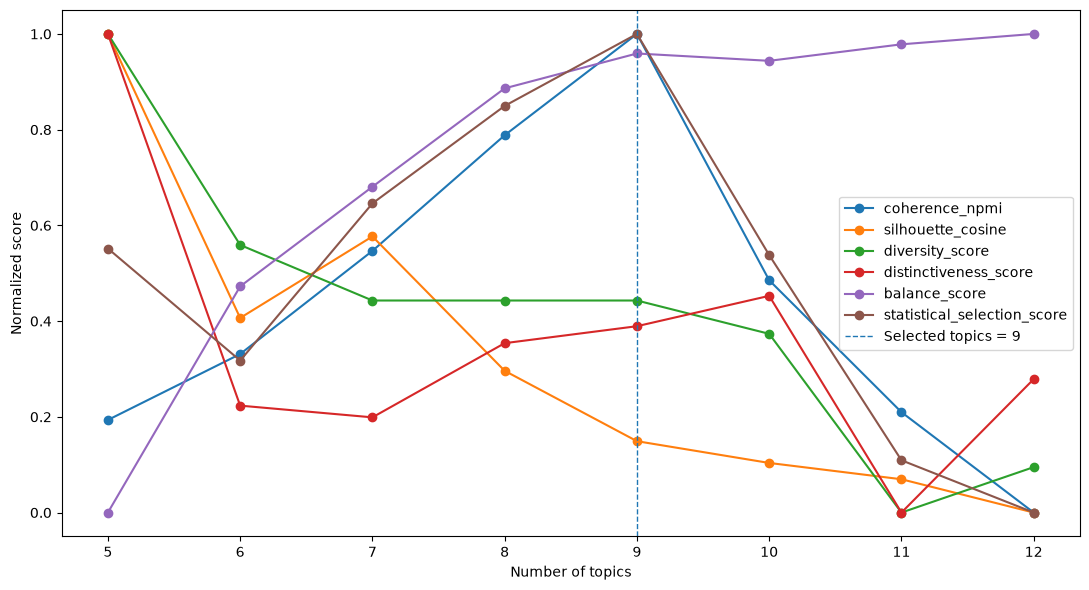

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/global/policy_global_nmf_topic_selection_metrics.png


In [11]:
# ==========================================
# Step 8: Plot global topic-number selection metrics
# ==========================================

plot_topic_selection_metrics(
    global_topic_number_search_df,
    GLOBAL_N_TOPICS,
    GLOBAL_IMG_DIR / "policy_global_nmf_topic_selection_metrics.png",
    "Policy NMF global topic-number selection",
)


In [12]:
# ==========================================
# Step 9: Fit final global NMF topic model
# ==========================================

global_results = fit_final_nmf_model(
    global_topic_data,
    n_topics=GLOBAL_N_TOPICS,
    output_dir=GLOBAL_OUT_DIR,
    output_prefix="policy_global_nmf",
    top_n_words=TOP_N_WORDS,
)

global_df = global_results["df"]
global_topic_info = global_results["topic_info"]
global_topic_distribution = global_results["topic_distribution"]
global_topic_keywords_df = global_results["topic_keywords"]
global_representative_docs_df = global_results["representative_documents"]

print("Global NMF model fitted.")
print("Global topics:", GLOBAL_N_TOPICS)

display(global_topic_info[["topic", "documents", "share", "keywords"]])
display(global_representative_docs_df.head(20))


Global NMF model fitted.
Global topics: 9


,topic,documents,share,keywords
0,0,277,0.147,"assessment, language, write, generate, feedback, content, teach, task, help, chatgpt, think, prompt"
1,1,149,0.079,"child, parent, sexual, child child, abuse, people, oco, recommender, unicef, council, child sexual, convention"
2,2,219,0.116,"usage, outils, cadre, données, pédagogique, établissements, déploiement, utilisation, numérique, pédagogiques, enjeux, usages"
3,3,199,0.105,"competency, design, knowledge, skill, framework, progression, competency framework, curriculum, aspect, knowledge skill, professional, ethical"
4,4,90,0.048,"cognitive, offload, load, cognitive load, metacognitive, critical, study, cognitive offload, learner, critical thinking, thinking, performance"
5,5,193,0.102,"strategy, learner, teach, teach assessment, assessment, progress, leader, skill, competence, framework, professional, pillar"
6,6,277,0.147,"principle, privacy, ethical, safety, security, protection, accountability, regulation, transparency, personal, risk, legal"
7,7,248,0.131,"staff, guidance, literacy, educator, integrity, step, academic, focus, academic integrity, professional, community, responsible"
8,8,236,0.125,"submission, recommendation, public, inquiry, research, analysis, evidence, body, people, group, university, tension"


,topic,representativeness_score,topic_confidence,topic_margin,doc_id,country,source_type,nmf_token_count,heading_context,nmf_source_text,nmf_clean_text
0,0,1.000000,1.000000,1.000000,policy_ai_in_australian_education_snapshot_principles_policy_and_practice_august_2023,australia,original,64,What is a large language model?,What is a large language model?. 2. Introduction to LLMs\n\nThe following section provides a non-technical introduction to a large language model and key terms and concepts whi...,large language introduction follow introduction large language term concepts integral large language large language perform variety natural language processing nlp task interac...
1,0,1.000000,1.000000,1.000000,policy_guidetoaiinschools,usa,original,51,A third student - a high school student from a suburban school in the South - described how he had used AI:,"A third student - a high school student from a suburban school in the South - described how he had used AI:\n\n'I would copy and paste the question. Whatever the answer was, I ...",high suburban south copy paste proofread big word know start run detector come detect submit write essay write essay later interviewer wish caught sense yeah interviewer away t...
2,0,1.000000,1.000000,1.000000,policy_guidetoaiinschools,usa,original,93,To Differentiate Instruction,"To Differentiate Instruction\n\nMegan Dinkla (3rd Grade Teacher, Winterset Elementary Winterset CSD): 'It's just taking those same words; it's just simplifying the vocabulary w...",differentiate instruction megan dinkla grade elementary csd word simplify vocabulary word easier accessible build competence build fluency group simple huge fall high perform s...
3,0,1.000000,1.000000,1.000000,policy_guidetoaiinschools,usa,original,68,To Assist with Feedback and Assessment,To Assist with Feedback and Assessment. To Differentiate Instruction\n\ndid common words for school supplies; we did common phrases when talking to friends; we've done math voc...,feedback assessment differentiate instruction common word supply common phrase talk friend math vocabulary selects language speak run tutor read native language audio feature t...
4,0,1.000000,1.000000,1.000000,policy_ahisa_member_survey_report_gen_ai_in_australian_independent_schools,australia,original,98,"Chart 9. Students' application of generative AI tools by order of number of mentions, expressed as a proportion of respondents selecting the item",4b. Ways generative AI tools are used by students\n\nRespondents were asked to select all items from a list of ways students might use generative AI tools that applied to stude...,item list apply order number mention express proportion item commonly research generate idea creative project offer feedback improve write check accessible definition concept c...
5,1,1.000000,1.000000,1.000000,policy_oco_ai_policy_spotlight_report,ireland,original,56,Recommendation:,Recommendation:\n\nIdentify and fill any gaps in Irish legislation relating to child sexual abuse and sexual exploitation facilitated by AI and child sexual abuse material gene...,recommendation fill gap legislation child sexual abuse sexual exploitation facilitate child sexual abuse material prohibition deepfake abuse amend legislation term child pornog...
6,1,1.000000,1.000000,1.000000,policy_oco_ai_policy_spotlight_report,ireland,original,50,Adopt a child rights-based approach,"Adopt a child rights-based approach\n\nthe culture change and legal landscape needed to ensure children's rights are fully respected, protected and fulfilled. A child rights ap...",adopt child culture legal landscape child fully protect fulfil child measure child uncrc legislation compliant crc business procedure redress harm root crc coordination child i...
7,1,1.000000,1.000000,1.000000,policy_oco_ai_policy_spotlight_report,ireland,original,101,Children's rights and digital environment references,"Children's rights and digital environment references\n\nThis image presents a set of children’s rights and

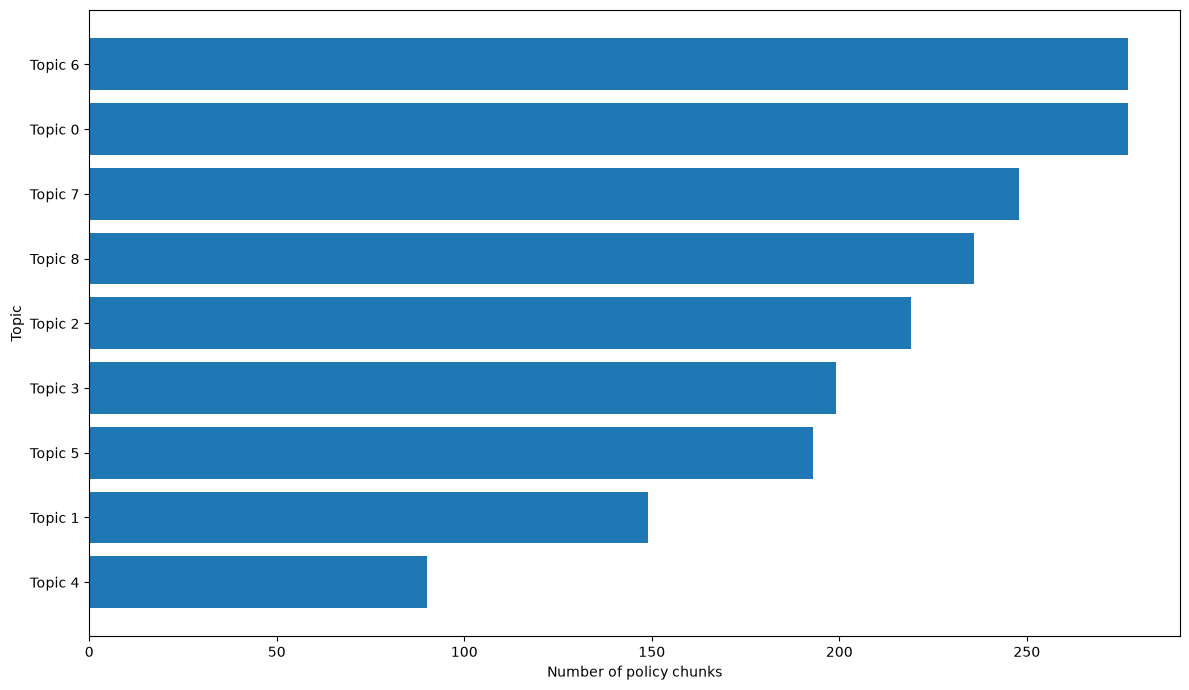

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/global/policy_global_nmf_topic_distribution.png


In [13]:
# ==========================================
# Step 10: Plot global topic distribution
# ==========================================

plot_topic_distribution(
    global_topic_info,
    GLOBAL_IMG_DIR / "policy_global_nmf_topic_distribution.png",
    "Policy NMF global topic distribution",
)


In [14]:
# ==========================================
# Step 11: Generate topic-level SLM labels and prototypes
# One SLM call per topic only
# ==========================================

def fallback_topic_label(keywords):
    terms = [term.strip() for term in str(keywords).split(",") if term.strip()]
    return " / ".join(terms[:4]) if terms else "Unlabelled topic"


def generate_slm_topic_labels(
    topic_info_df,
    representative_docs_df,
    output_dir,
    output_prefix,
    corpus_description,
):
    if not SLM_AVAILABLE:
        raise RuntimeError(
            "SLM is not available. Stop here instead of silently using fallback labels. "
            "Check model loading, HF_TOKEN, torch, device memory, and transformers version. "
            "To skip SLM labels, comment out this cell and use the topic keywords directly."
        )

    topic_labels_rows = []

    for _, row in topic_info_df.iterrows():
        topic_id = int(row["topic"])
        keywords = str(row["keywords"])

        topic_representatives = representative_docs_df[
            representative_docs_df["topic"].eq(topic_id)
        ].copy()

        if "representativeness_score" in topic_representatives.columns:
            topic_representatives = topic_representatives.sort_values(
                "representativeness_score",
                ascending=False,
            )

        topic_representatives = topic_representatives.head(4)

        representative_snippets = []

        for _, doc_row in topic_representatives.iterrows():
            snippet = str(doc_row.get("nmf_source_text", ""))
            snippet = re.sub(r"\s+", " ", snippet).strip()
            representative_snippets.append(snippet[:800])

        label_prompt = f"""
You are labelling one topic from a policy corpus about AI, education, youth, digital technology, governance, safety, rights, and public institutions.

Corpus scope:
{corpus_description}

Your task is to produce a specific, human-readable topic label.

Top keywords:
{keywords}

Representative policy excerpts:
{chr(10).join('- ' + snippet for snippet in representative_snippets[:3])}

Return exactly one valid JSON object with this schema:
{{
  "label": "specific policy topic label, 5 to 12 words",
  "prototype": "one clear sentence describing the policy theme",
  "policy_area": "short policy area",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": ""
}}

Label rules:
- Do NOT use generic labels such as "AI Policy", "Digital Policy", "Education Policy", or "Technology Governance".
- The label must mention the concrete policy mechanism, actor, institution, or setting.
- Prefer labels like:
  "School AI Governance and Institutional Accountability"
  "Child Data Protection and Online Safety Duties"
  "Teacher Training Requirements for Digital Education"
  "National AI Strategy and Public-Sector Implementation"
- If the topic is about education, say what part: school governance, teacher training, assessment, curriculum, student protection, procurement.
- If the topic is about governance, say what mechanism: regulation, guidance, oversight, risk management, accountability, data protection.
- Use double quotes.
- Use true or false, not True or False.
- Do not include Markdown.
- Do not include explanations outside JSON.
""".strip()

        slm_raw = slm_generate(label_prompt, max_new_tokens=LABEL_SLM_MAX_NEW_TOKENS)
        slm_json = extract_json_object(slm_raw)

        print(f"\nTopic {topic_id} SLM raw response:")
        print(slm_raw[:500])

        if not slm_json:
            raise RuntimeError(
                f"Could not parse SLM JSON for topic {topic_id}. Raw response:\n{slm_raw}"
            )

        label = str(slm_json.get("label", "")).strip()
        prototype = str(slm_json.get("prototype", "")).strip()

        if not label:
            label = fallback_topic_label(keywords)

        if not prototype:
            prototype = f"Policy topic about {fallback_topic_label(keywords)}."

        topic_labels_rows.append({
            "topic": topic_id,
            "topic_label": label,
            "topic_prototype": prototype,
            "policy_area": str(slm_json.get("policy_area", "")).strip(),
            "is_coherent": slm_json.get("is_coherent", ""),
            "artifact_topic": slm_json.get("artifact_topic", ""),
            "merge_hint": str(slm_json.get("merge_hint", "")).strip(),
            "keywords": keywords,
            "slm_raw_response": slm_raw,
        })

    topic_labels_df = pd.DataFrame(topic_labels_rows)

    topic_labels_df.to_csv(
        output_dir / f"{output_prefix}_topic_labels_final.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return topic_labels_df


global_topic_labels_df = generate_slm_topic_labels(
    global_topic_info,
    global_representative_docs_df,
    GLOBAL_OUT_DIR,
    "policy_global_nmf",
    corpus_description="Global policy documents, including country-specific and international/UNESCO material.",
)

global_topic_label_map = dict(
    zip(global_topic_labels_df["topic"], global_topic_labels_df["topic_label"])
)

global_topic_prototype_map = dict(
    zip(global_topic_labels_df["topic"], global_topic_labels_df["topic_prototype"])
)

global_df["topic_label"] = global_df["topic"].map(global_topic_label_map)
global_df["topic_prototype"] = global_df["topic"].map(global_topic_prototype_map)

global_topic_info = global_topic_info.merge(
    global_topic_labels_df[
        [
            "topic",
            "topic_label",
            "topic_prototype",
            "policy_area",
            "is_coherent",
            "artifact_topic",
            "merge_hint",
        ]
    ],
    on="topic",
    how="left",
)

global_df.to_csv(
    GLOBAL_OUT_DIR / "policy_global_nmf_documents_with_topic_labels_final.csv",
    index=False,
    encoding="utf-8-sig",
)

global_topic_info.to_csv(
    GLOBAL_OUT_DIR / "policy_global_nmf_topic_info_with_labels_final.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Global SLM topic labels complete.")
display(global_topic_labels_df[[
    "topic",
    "topic_label",
    "topic_prototype",
    "policy_area",
    "is_coherent",
    "artifact_topic",
    "merge_hint",
]])



Topic 0 SLM raw response:
```json
{
  "label": "AI-Assisted Learning Assessment Protocols",
  "prototype": "AI tools enhance educational assessments by providing instant feedback and personalized learning paths.",
  "policy_area": "education",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Focus on protocols and mechanisms rather than specific technologies."
}
```

Topic 1 SLM raw response:
```json
{
  "label": "AI Child Protection and Rights",
  "prototype": "Developing policies to protect children from AI-related harm and ensuring their rights are upheld.",
  "policy_area": "AI Governance and Legal Frameworks",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge into existing AI policy discussions focusing on child welfare."
}
```

Topic 2 SLM raw response:
```json
{
  "label": "AI Usage and Pedagogy in School Governance",
  "prototype": "The integration of artificial intelligence into educational systems and its impact on school governance."

,topic,topic_label,topic_prototype,policy_area,is_coherent,artifact_topic,merge_hint
0,0,AI-Assisted Learning Assessment Protocols,AI tools enhance educational assessments by providing instant feedback and personalized learning paths.,education,True,False,Focus on protocols and mechanisms rather than specific technologies.
1,1,AI Child Protection and Rights,Developing policies to protect children from AI-related harm and ensuring their rights are upheld.,AI Governance and Legal Frameworks,True,False,Merge into existing AI policy discussions focusing on child welfare.
2,2,AI Usage and Pedagogy in School Governance,The integration of artificial intelligence into educational systems and its impact on school governance.,school governance,True,False,Merge with 'AI in Education' if broader context includes both.
3,3,AI Competency Framework and Curriculum Development,Developing AI competencies through structured frameworks and curricula.,AI Competency Framework,True,False,Merge with existing policies related to AI education and professional development.
4,4,Cognitive Offloading in AI-Assisted Education,Exploring the impact of AI-driven cognitive offloading on educational outcomes.,Education,True,False,Focus on the role of AI in altering cognitive demands and its implications for educational practices.
5,5,Digital Learning Frameworks and Assessment Policies,Strategies to enhance digital learning frameworks and improve assessment practices within educational systems.,Educational Systems,True,False,Merge with 'Assessment Reform' if focusing on evaluation methods.
6,6,AI Ethical Guidelines and School Data Protection,International guidelines on AI ethics and data protection in educational settings.,AI Governance and School Data Protection,True,False,Merge with existing policies focusing on AI ethics and data protection in education.
7,7,AI Educator Guidance and Professional Development,Guidance and support for educators on using AI responsibly and effectively.,Educational Practices,True,False,Focus on best practices and ethical considerations in AI integration.
8,8,AI Curriculum Development and School Oversight,The role of AI in educational curricula and its impact on school governance.,education,True,False,


In [15]:
# ==========================================
# Step 12: Global topic distribution by country
# ==========================================

unknown_country_values = {"unknown", "", "nan", "none"}

global_df["country_display"] = (
    global_df["country"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)

global_df["country_display"] = global_df["country_display"].apply(
    lambda value: "International / UNESCO"
    if value in unknown_country_values
    else value
)

global_topic_country_counts = (
    global_df.groupby(["topic", "country_display"])
    .size()
    .reset_index(name="documents")
)

global_topic_totals = (
    global_df.groupby("topic")
    .size()
    .reset_index(name="topic_total")
)

global_topic_country_distribution = (
    global_topic_country_counts
    .merge(global_topic_totals, on="topic", how="left")
)

global_topic_country_distribution["share_within_topic"] = (
    global_topic_country_distribution["documents"]
    / global_topic_country_distribution["topic_total"]
)

global_topic_country_distribution = (
    global_topic_country_distribution
    .merge(global_topic_keywords_df[["topic", "keywords"]], on="topic", how="left")
    .merge(global_topic_labels_df[["topic", "topic_label"]], on="topic", how="left")
    .sort_values(["topic", "documents"], ascending=[True, False])
    .reset_index(drop=True)
)

global_country_topic_matrix = pd.crosstab(
    global_df["country_display"],
    global_df["topic"],
    normalize="index",
)

global_topic_country_distribution.to_csv(
    GLOBAL_OUT_DIR / "policy_global_nmf_topic_country_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)

global_country_topic_matrix.to_csv(
    GLOBAL_OUT_DIR / "policy_global_nmf_country_topic_matrix.csv",
    encoding="utf-8-sig",
)

print("Country distribution inside each global topic:")
display(global_topic_country_distribution)

print("\nGlobal-topic share within each country / international group:")
display(global_country_topic_matrix)


Country distribution inside each global topic:


,topic,country_display,documents,topic_total,share_within_topic,keywords,topic_label
0,0,usa,167,277,0.602888,"assessment, language, write, generate, feedback, content, teach, task, help, chatgpt, think, prompt",AI-Assisted Learning Assessment Protocols
1,0,australia,54,277,0.194946,"assessment, language, write, generate, feedback, content, teach, task, help, chatgpt, think, prompt",AI-Assisted Learning Assessment Protocols
2,0,france,29,277,0.104693,"assessment, language, write, generate, feedback, content, teach, task, help, chatgpt, think, prompt",AI-Assisted Learning Assessment Protocols
3,0,ireland,27,277,0.097473,"assessment, language, write, generate, feedback, content, teach, task, help, chatgpt, think, prompt",AI-Assisted Learning Assessment Protocols
4,1,ireland,126,149,0.845638,"child, parent, sexual, child child, abuse, people, oco, recommender, unicef, council, child sexual, convention",AI Child Protection and Rights
5,1,usa,14,149,0.093960,"child, parent, sexual, child child, abuse, people, oco, recommender, unicef, council, child sexual, convention",AI Child Protection and Rights
6,1,australia,8,149,0.053691,"child, parent, sexual, child child, abuse, people, oco, recommender, unicef, council, child sexual, convention",AI Child Protection and Rights
7,1,france,1,149,0.006711,"child, parent, sexual, child child, abuse, people, oco, recommender, unicef, council, child sexual, convention",AI Child Protection and Rights
8,2,france,219,219,1.000000,"usage, outils, cadre, données, pédagogique, établissements, déploiement, utilisation, numérique, pédagogiques, enjeux, usages",AI Usage and Pedagogy in School Governance
9,3,International / UNESCO,176,199,0.884422,"competency, design, knowledge, skill, framework, progression, competency framework, curriculum, aspect, knowledge skill, professional, ethical",AI Competency Framework and Curriculum Development



Global-topic share within each country / international group:


topic,0,1,2,3,4,5,6,7,8
country_display,,,,,,,,,
International / UNESCO,0.000000,0.000000,0.000000,0.811060,0.000000,0.036866,0.115207,0.000000,0.036866
australia,0.136364,0.020202,0.000000,0.015152,0.191919,0.045455,0.282828,0.111111,0.196970
france,0.088957,0.003067,0.671779,0.018405,0.009202,0.021472,0.092025,0.000000,0.095092
ireland,0.064748,0.302158,0.000000,0.011990,0.000000,0.330935,0.100719,0.057554,0.131894
usa,0.313910,0.026316,0.000000,0.011278,0.020677,0.041353,0.127820,0.338346,0.120301


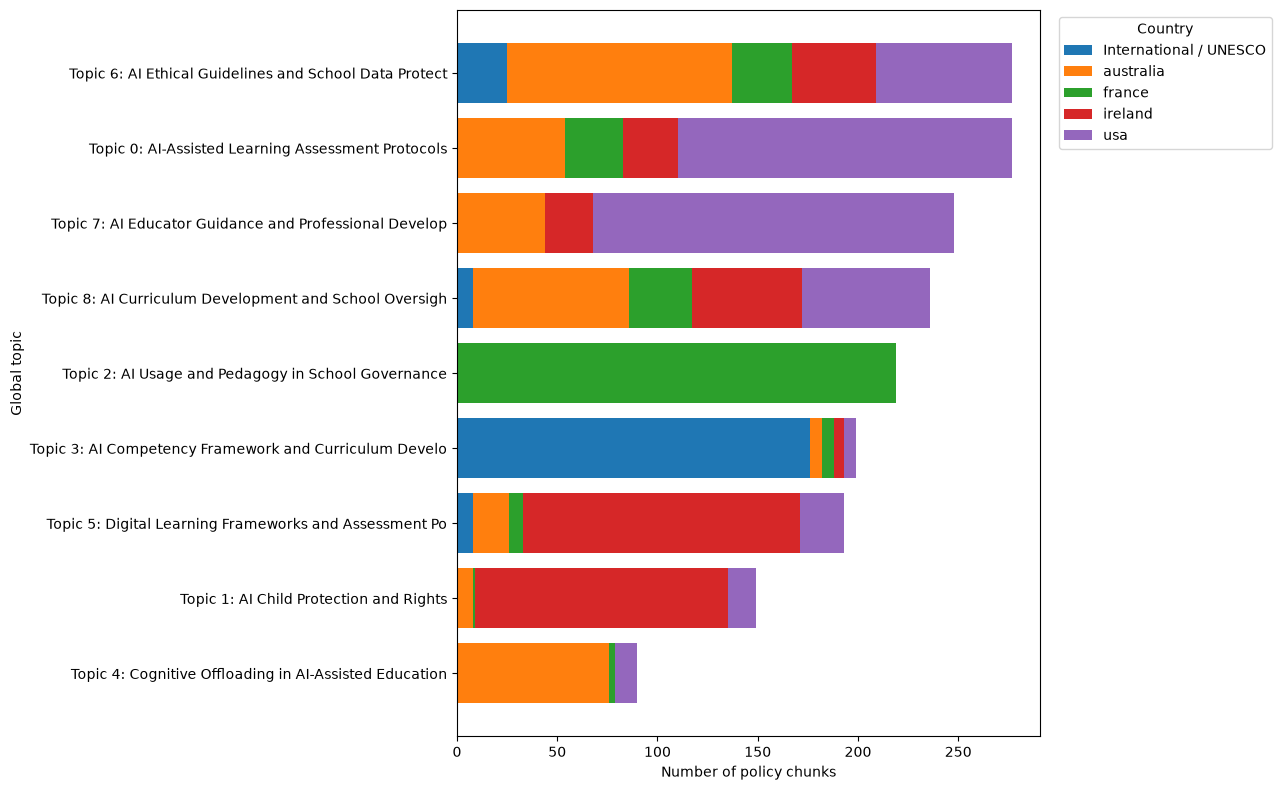

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/global/policy_global_nmf_topic_distribution_by_country.png


In [16]:
# ==========================================
# Step 13: Plot global topic distribution by country
# ==========================================

country_topic_plot_df = global_topic_country_distribution.copy()

country_topic_plot_df["topic_display"] = (
    "Topic "
    + country_topic_plot_df["topic"].astype(int).astype(str)
)

if "topic_label" in country_topic_plot_df.columns:
    country_topic_plot_df["topic_display"] = (
        country_topic_plot_df["topic_display"]
        + ": "
        + country_topic_plot_df["topic_label"].fillna("").astype(str).str.slice(0, 45)
    )

country_topic_pivot = country_topic_plot_df.pivot_table(
    index="topic_display",
    columns="country_display",
    values="documents",
    aggfunc="sum",
    fill_value=0,
)

country_topic_pivot = country_topic_pivot.loc[
    country_topic_pivot.sum(axis=1).sort_values(ascending=True).index
]

plt.figure(figsize=(13, 8))

bottom = np.zeros(len(country_topic_pivot))

for country in country_topic_pivot.columns:
    values = country_topic_pivot[country].to_numpy()

    plt.barh(
        country_topic_pivot.index,
        values,
        left=bottom,
        label=country,
    )

    bottom = bottom + values

plt.xlabel("Number of policy chunks")
plt.ylabel("Global topic")
# plt.title("Policy NMF global topics by country")
plt.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()

save_path = GLOBAL_IMG_DIR / "policy_global_nmf_topic_distribution_by_country.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", save_path)


Countries included in per-country discovery:


,chunks
country,
usa,532
ireland,417
australia,396
france,326



Excluded from per-country discovery, but kept in global discovery:


,excluded_doc_id
0,policy_ai_competency_framework_for_students
123,policy_ai_competency_framework_for_teachers


Country: australia
Chunks: 396
Evaluating 3 NMF topics...
Evaluating 4 NMF topics...
Evaluating 5 NMF topics...
Evaluating 6 NMF topics...
Evaluating 7 NMF topics...
Evaluating 8 NMF topics...
Evaluating 9 NMF topics...
Evaluating 10 NMF topics...


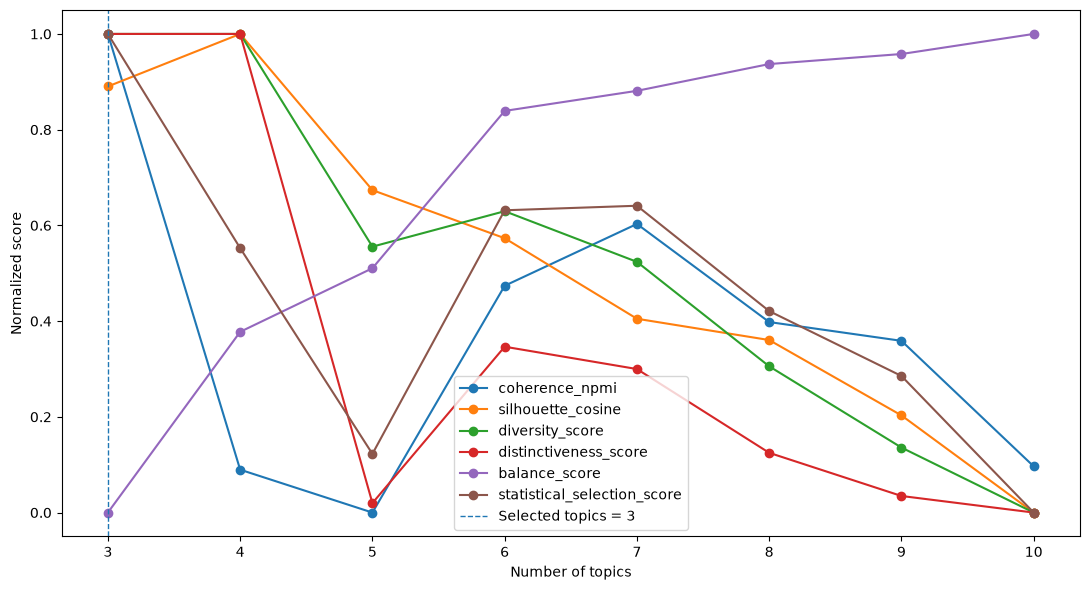

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/australia/policy_australia_nmf_topic_selection_metrics.png

Topic 0 SLM raw response:
```json
{
  "label": "AI Ethics Guidelines and Staff Training",
  "prototype": "Developing ethical guidelines and ensuring staff training on AI ethics principles.",
  "policy_area": "AI Governance and Staff Training",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Consider integrating AI ethics into regular staff training programs."
}
```

Topic 1 SLM raw response:
```json
{
  "label": "Cognitive Offloading in Education",
  "prototype": "Exploring how AI can optimize learning processes through cognitive offloading.",
  "policy_area": "Education",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Focus on the benefits and mechanisms of cognitive offloading in educational settings."
}
```

Topic 2 SLM raw response:
```json
{
  "label": "AI Governance and Stakeholder Engagement i

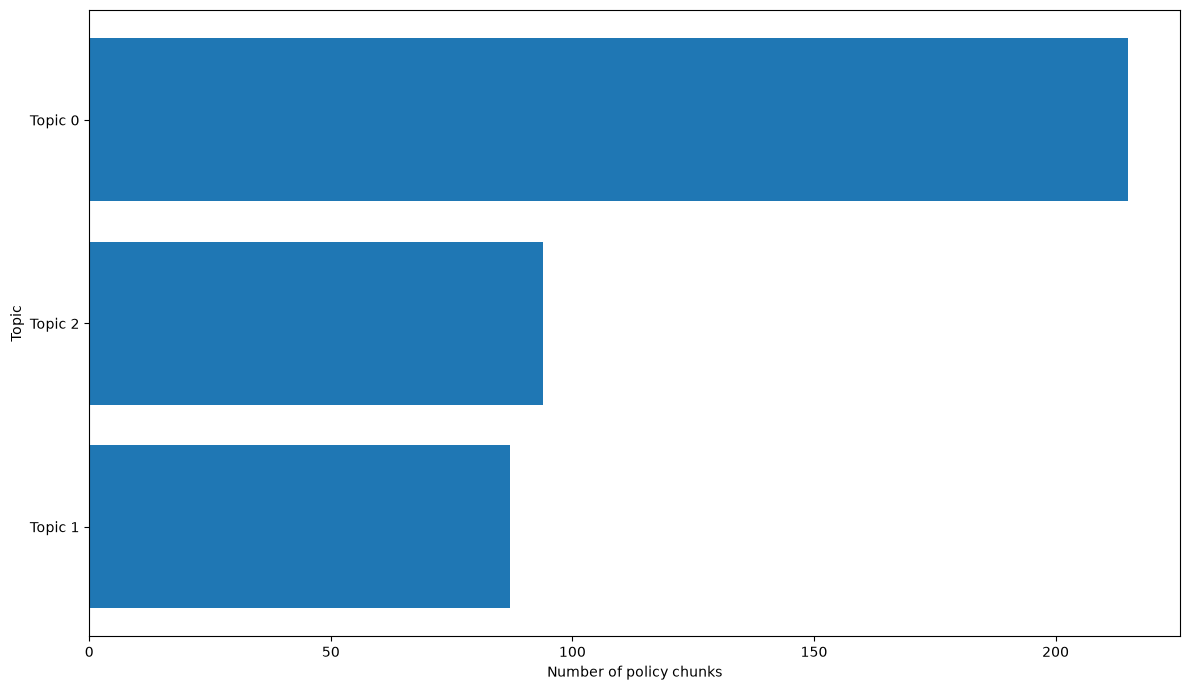

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/australia/policy_australia_nmf_topic_distribution.png
Selected topics for australia: 3


,topic,documents,share,keywords,Name,topic_label,topic_prototype,policy_area,is_coherent,artifact_topic,merge_hint
0,0,215,0.543,"principle, privacy, framework, ethical, staff, teach, child, transparency, assessment, guidance, guideline, security",0_principle_privacy_framework_ethical,AI Ethics Guidelines and Staff Training,Developing ethical guidelines and ensuring staff training on AI ethics principles.,AI Governance and Staff Training,True,False,Consider integrating AI ethics into regular staff training programs.
1,1,87,0.220,"cognitive, offload, load, critical, metacognitive, study, cognitive load, learner, thinking, critical thinking, knowledge, cognitive offload",1_cognitive_offload_load_critical,Cognitive Offloading in Education,Exploring how AI can optimize learning processes through cognitive offloading.,Education,True,False,Focus on the benefits and mechanisms of cognitive offloading in educational settings.
2,2,94,0.237,"submission, recommendation, inquiry, analysis, evidence, tension, body, public, group, value, university, material",2_submission_recommendation_inquiry_analysis,AI Governance and Stakeholder Engagement in Education,Exploring the role of AI in educational policies and stakeholder engagement.,education,True,False,"This label captures the core themes of AI integration in education, stakeholder involvement, and governance."


Country: france
Chunks: 326
Evaluating 3 NMF topics...
Evaluating 4 NMF topics...
Evaluating 5 NMF topics...
Evaluating 6 NMF topics...
Evaluating 7 NMF topics...
Evaluating 8 NMF topics...
Evaluating 9 NMF topics...
Evaluating 10 NMF topics...


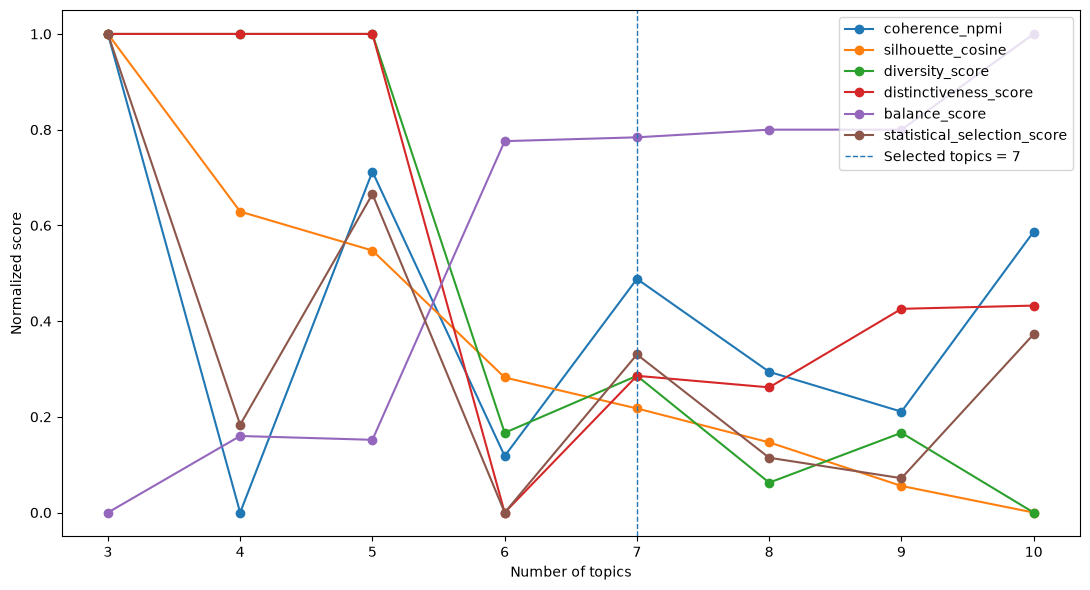

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/france/policy_france_nmf_topic_selection_metrics.png

Topic 0 SLM raw response:
```json
{
  "label": "National AI Curriculum Development and School Coordination",
  "prototype": "The French government plans to develop an AI curriculum for schools while coordinating efforts across different levels of administration.",
  "policy_area": "AI in Education",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge with 'National AI Curriculum Development and School Coordination'"
}
```

Topic 1 SLM raw response:
```json
{
  "label": "France's National AI Strategy and Funding",
  "prototype": "France invests heavily in AI through strategic planning and significant funding.",
  "policy_area": "AI Strategy and Funding",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Investment in AI includes both public and private sectors."
}
```

Topic 2 SLM raw response:
```json
{
  "

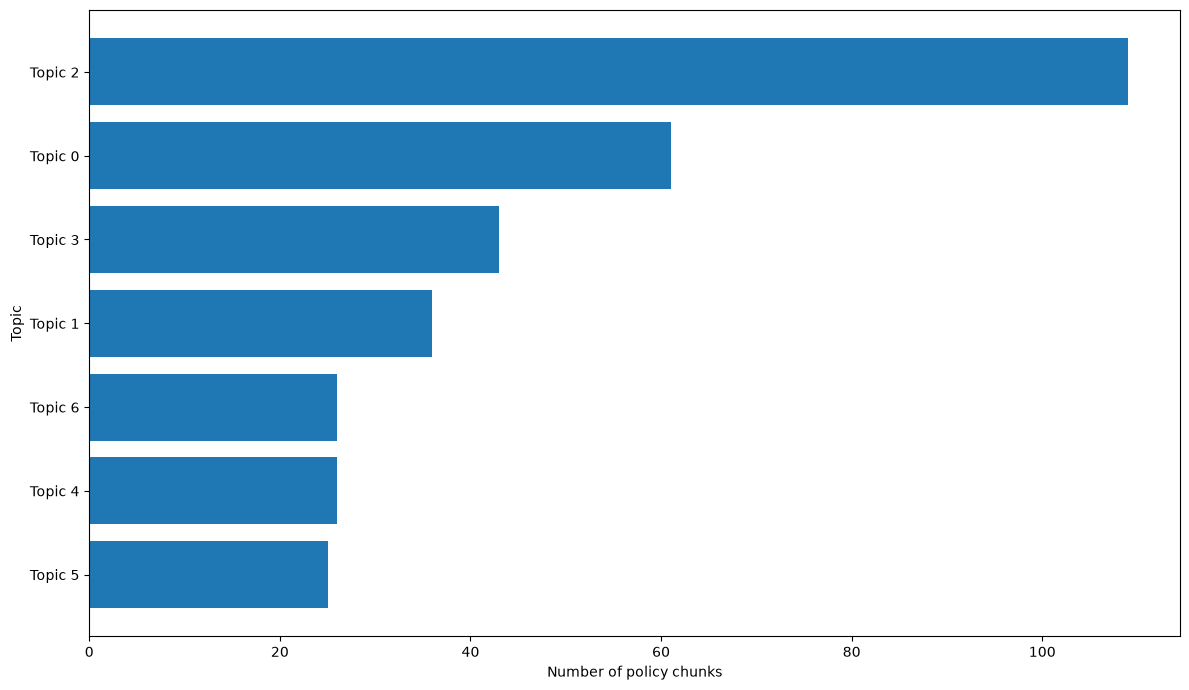

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/france/policy_france_nmf_topic_distribution.png
Selected topics for france: 7


,topic,documents,share,keywords,Name,topic_label,topic_prototype,policy_area,is_coherent,artifact_topic,merge_hint
0,0,61,0.187,"déploiement, établissements, place, acteurs, mise, niveau, cadre, sein, outils, mise place, usage, entre",0_déploiement_établissements_place_acteurs,National AI Curriculum Development and School Coordination,The French government plans to develop an AI curriculum for schools while coordinating efforts across different levels of administration.,AI in Education,True,False,Merge with 'National AI Curriculum Development and School Coordination'
1,1,36,0.110,"investment, research, strategy, compute, public, fund, company, phase, economic, power, european, global",1_investment_research_strategy_compute,France's National AI Strategy and Funding,France invests heavily in AI through strategic planning and significant funding.,AI Strategy and Funding,True,False,Investment in AI includes both public and private sectors.
2,2,109,0.334,"données, usage, outils, utilisation, évaluation, critique, cadre, pédagogique, ressources, risques, utiliser, génératives",2_données_usage_outils_utilisation,AI in Education and Pédagogical Practices,"Éduquer à l'IA : comprendre les enjeux éducatifs et éthiques, maîtriser l'utilisation et l'évaluation des outils IA, respecter les droits des jeunes et garantir la sécurité num...",Éducation et pédagogie,True,False,"Utilisez ce label pour aborder les aspects éducatifs et pédagogiques concernant l'IA, y compris la formation des enseignants, l'utilisation des outils IA, et la protection des ..."
3,3,43,0.132,"language, chatgpt, teach, source, assessment, large, task, user, module, response, prompt, word",3_language_chatgpt_teach_source,Large Language Models in Educational Technology,Exploring the role of large language models in enhancing educational technology.,Education,True,False,"Focus on how these models can improve teaching methods, accessibility, and personalized learning experiences."
4,4,26,0.080,"court, legal, patent, precedent, protect, regulation, decision, cnil, creative, protection, intellectual, property",4_court_legal_patent_precedent,French AI Law and Regulation,France's approach to regulating AI through legal precedents and court rulings.,AI Law and Regulation,True,False,
5,5,25,0.077,"répondants, questionnaire, réponses, oui, extrait, manque, usage, temp, répondants répondants, extrait questionnaire, freins, sais",5_répondants_questionnaire_réponses_oui,"AI in French Schools: Usage, Responses, and Challenges",French schools implementing AI tools and their impact on teaching methods.,Education,True,False,Merge with 'AI in School Management Systems'
6,6,26,0.080,"numérique, recherche, académique, unesco, directeur, adjoint, billet, billet recherche, académie, directrice, délégué, lycée",6_numérique_recherche_académique_unesco,Academic Digital Transformation Leadership in France,France's approach to integrating digital technologies into academic leadership roles.,Academic Governance,True,False,Focus on the role of directors and deputy-directors in implementing digital strategies.


Country: ireland
Chunks: 417
Evaluating 3 NMF topics...
Evaluating 4 NMF topics...
Evaluating 5 NMF topics...
Evaluating 6 NMF topics...
Evaluating 7 NMF topics...
Evaluating 8 NMF topics...
Evaluating 9 NMF topics...
Evaluating 10 NMF topics...


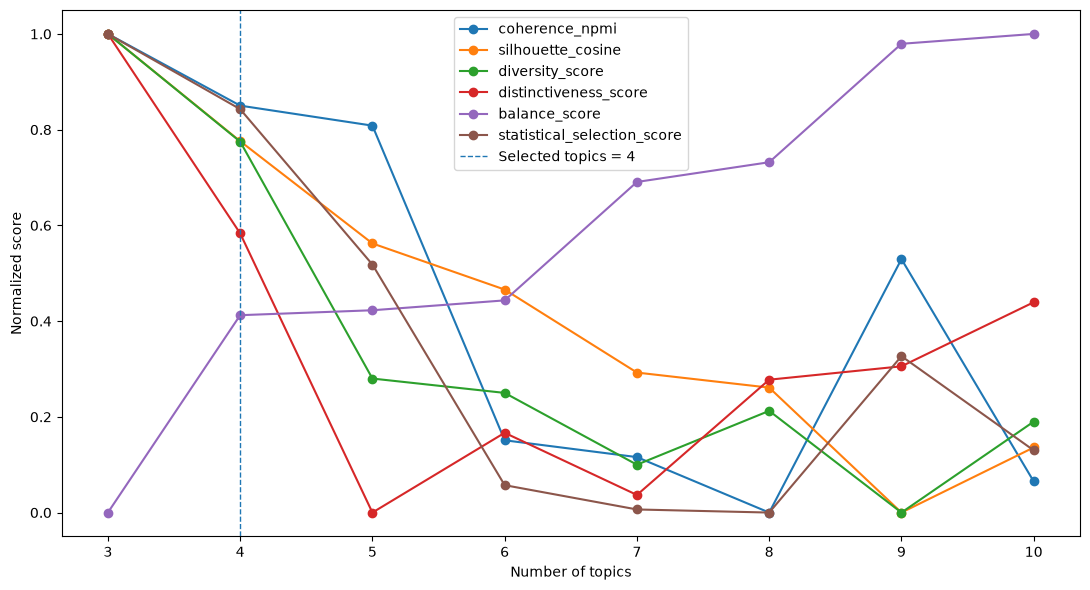

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/ireland/policy_ireland_nmf_topic_selection_metrics.png

Topic 0 SLM raw response:
```json
{
  "label": "Child Sexual Abuse and AI Regulation",
  "prototype": "Addressing child sexual abuse and its facilitation through AI requires comprehensive legislation.",
  "policy_area": "AI Regulations and Child Protection",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge with existing policies addressing AI ethics and cybersecurity."
}
```

Topic 1 SLM raw response:
```json
{
  "label": "Digital Learning Framework and Teacher Competence Development",
  "prototype": "The Digital Strategy aims to establish a comprehensive framework for integrating digital technologies into education.",
  "policy_area": "Digital Technology",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge with 'Educational Technology' if focusing solely on tech implementation."
}
```

Topic 2 SL

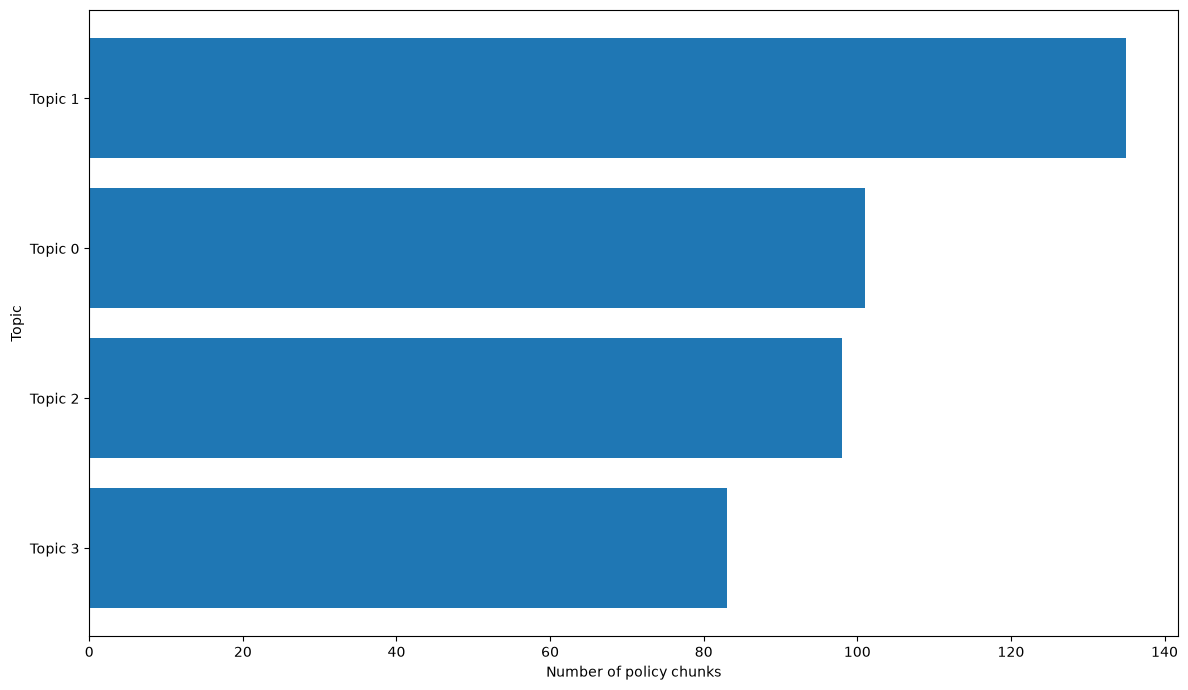

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/ireland/policy_ireland_nmf_topic_distribution.png
Selected topics for ireland: 4


,topic,documents,share,keywords,Name,topic_label,topic_prototype,policy_area,is_coherent,artifact_topic,merge_hint
0,0,101,0.242,"child, sexual, parent, research, abuse, child child, oco, international, recommender, child sexual, protection, sexual abuse",0_child_sexual_parent_research,Child Sexual Abuse and AI Regulation,Addressing child sexual abuse and its facilitation through AI requires comprehensive legislation.,AI Regulations and Child Protection,True,False,Merge with existing policies addressing AI ethics and cybersecurity.
1,1,135,0.324,"strategy, learner, teach, skill, professional, leader, teach assessment, assessment, progress, competence, framework, curriculum",1_strategy_learner_teach_skill,Digital Learning Framework and Teacher Competence Development,The Digital Strategy aims to establish a comprehensive framework for integrating digital technologies into education.,Digital Technology,True,False,Merge with 'Educational Technology' if focusing solely on tech implementation.
2,2,98,0.235,"public, people, disability, body, recommendation, act, regulation, disabled people, disabled, council, office, sector",2_public_people_disability_body,Public AI Oversight and Rights Compliance,The State should establish robust mechanisms for public oversight and ensure AI systems comply with human rights standards.,AI Governance and Rights,True,False,Merge with existing policies addressing AI ethics and public engagement.
3,3,83,0.199,"content, staff, source, bias, academic, accuracy, personal, assessment, generate, limitation, tutor, response",3_content_staff_source_bias,Artificial Intelligence Assessment and Academic Misconduct,Regulation of AI use in assessments and academic integrity.,Academic Integrity and Assessment,True,False,Merge with existing policies on academic integrity and assessment.


Country: usa
Chunks: 532
Evaluating 3 NMF topics...
Evaluating 4 NMF topics...
Evaluating 5 NMF topics...
Evaluating 6 NMF topics...
Evaluating 7 NMF topics...
Evaluating 8 NMF topics...
Evaluating 9 NMF topics...
Evaluating 10 NMF topics...


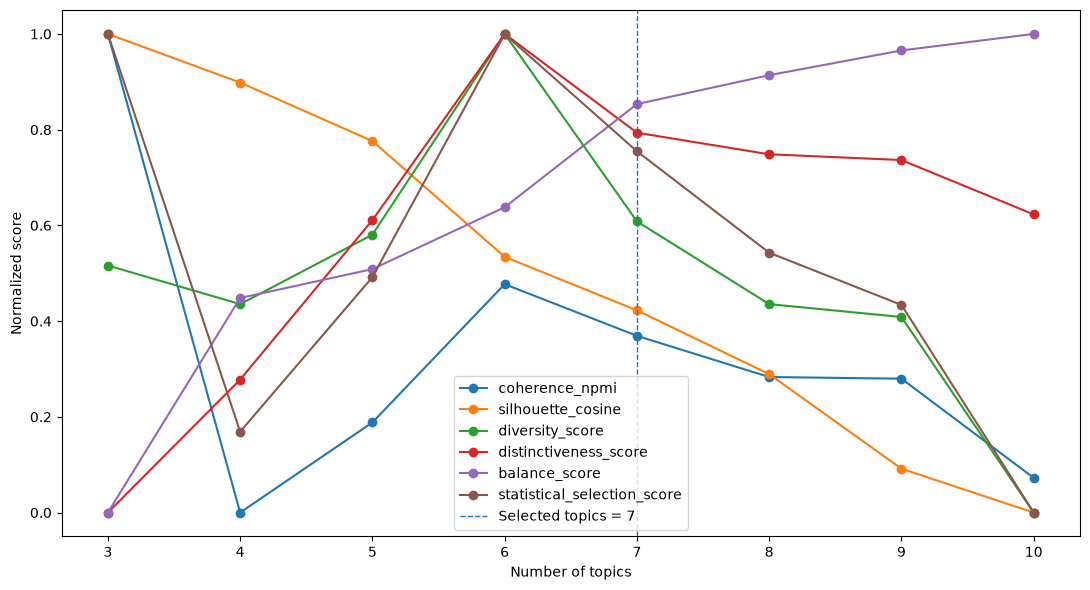

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/usa/policy_usa_nmf_topic_selection_metrics.png

Topic 0 SLM raw response:
```json
{
  "label": "Adaptive Learning and Personalized Instruction in Educational Technology",
  "prototype": "The focus on personalized instruction through adaptive learning technologies.",
  "policy_area": "EdTech",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge with topics related to educational technology and personalization."
}
```

Topic 1 SLM raw response:
```json
{
  "label": "AI-Assisted Learning and Academic Integrity",
  "prototype": "Students increasingly rely on AI tools for academic tasks, raising concerns about fairness, originality, and ethical standards.",
  "policy_area": "Academic Integrity and Fairness",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Consider merging with 'AI-Guided Assessment and Evaluation Practices'"
}
```

Topic 2 SLM raw response:
```js

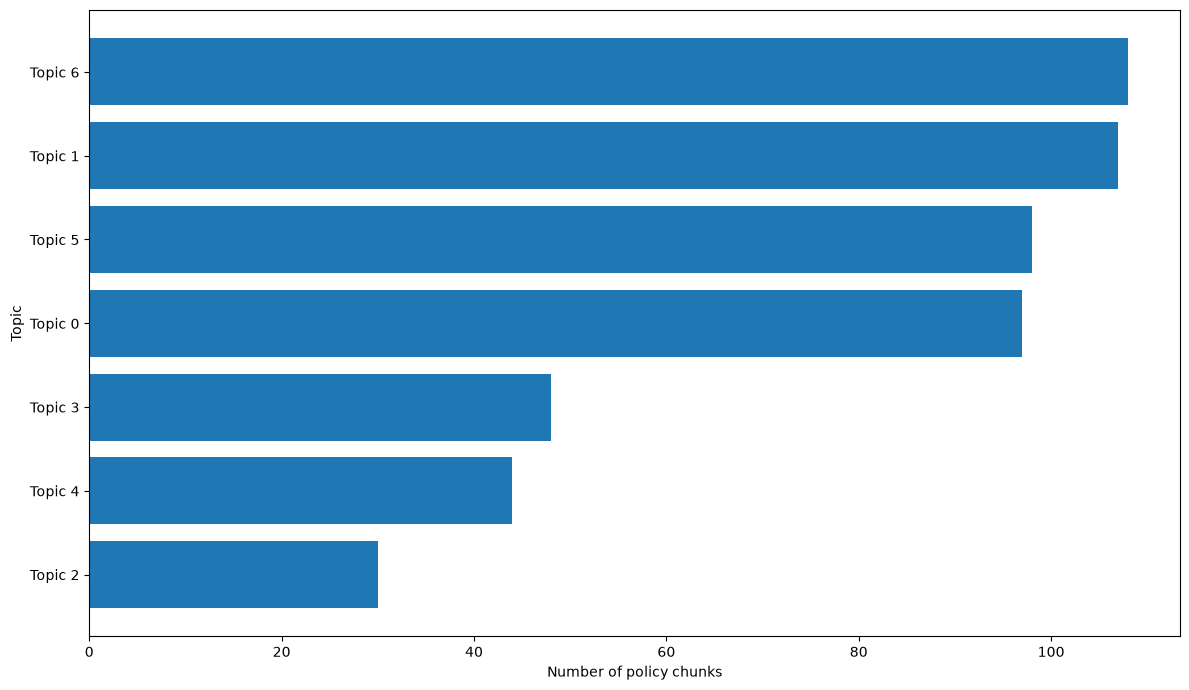

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/usa/policy_usa_nmf_topic_distribution.png
Selected topics for usa: 7


,topic,documents,share,keywords,Name,topic_label,topic_prototype,policy_area,is_coherent,artifact_topic,merge_hint
0,0,97,0.182,"context, research, learner, edtech, recommendation, advance, decision, people, pattern, educator, design, adaptivity",0_context_research_learner_edtech,Adaptive Learning and Personalized Instruction in Educational Technology,The focus on personalized instruction through adaptive learning technologies.,EdTech,True,False,Merge with topics related to educational technology and personalization.
1,1,107,0.201,"write, think, english, high, know, teach, assignment, thing, time, class, come, science",1_write_think_english_high,AI-Assisted Learning and Academic Integrity,"Students increasingly rely on AI tools for academic tasks, raising concerns about fairness, originality, and ethical standards.",Academic Integrity and Fairness,True,False,Consider merging with 'AI-Guided Assessment and Evaluation Practices'
2,2,30,0.056,"assessment, formative, formative assessment, feedback, teach, tutor, bias, journal, bias fairness, help, essay, focus",2_assessment_formative_formative assessment_feedback,Formative Assessment and Bias in AI-Guided Teaching,The role of AI in enhancing formative assessment while addressing potential biases within educational systems.,Assessment and Fairness in Educational Technology,True,False,Merge into broader themes related to AI in education and its impact on fairness and transparency.
3,3,48,0.090,"step, focus, action step, action, potential action, forward, step forward, legal, team, step step, reflection, share",3_step_focus_action step_action,Action Planning and Reflection in AI Governance,Guiding principles for implementing AI policies in educational settings.,AI Governance,True,False,Focus on the process of creating actionable plans and reflecting on their implementation.
4,4,44,0.083,"achievement, math, disadvantage, effect, regression, socioeconomic, math achievement, socioeconomic disadvantage, comparison, inequality, significant, year",4_achievement_math_disadvantage_effect,AI Access and Socioeconomic Disadvantage Effects on Math and ELA Achievement,The impact of AI access on educational outcomes among disadvantaged students.,Education,True,False,
5,5,98,0.184,"privacy, staff, protection, act, child, trust, security, safety, risk, review, personal, compliance",5_privacy_staff_protection_act,Student Privacy and Digital Technology Oversight,Federal regulations and state laws governing student data privacy and digital technology usage.,Schools and Districts,True,False,"Merge with existing policies related to data protection, online safety, and institutional accountability."
6,6,108,0.203,"literacy, guidance, educator, framework, integrate, leader, medium, equity, ethical, integration, staff, curriculum",6_literacy_guidance_educator_framework,Massachusetts AI Guidance for K-12 Education,Massachusetts provides guidelines for implementing artificial intelligence in K-12 education.,K-12 AI Implementation,True,False,


Per-country model summary:


,country,documents_used,selected_topics,largest_topic_share,output_folder,image_folder
0,australia,396,3,0.543,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/per_country/australia,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/australia
1,france,326,7,0.334,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/per_country/france,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/france
2,ireland,417,4,0.324,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/per_country/ireland,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/ireland
3,usa,532,7,0.203,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/per_country/usa,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/usa


In [17]:
# ==========================================
# Step 14: Per-country NMF topic discovery
# No synthetic data is used.
# ==========================================

RUN_PER_COUNTRY_DISCOVERY = True
RUN_PER_COUNTRY_SLM_LABELS = True

MIN_COUNTRY_DOCUMENTS = 80
COUNTRY_TOPIC_SEARCH_MIN_TOPICS = 3
COUNTRY_TOPIC_SEARCH_MAX_TOPICS = 10

excluded_country_values = {"unknown", "", "nan", "none"}

per_country_df = df[
    ~df["country"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(excluded_country_values)
].copy()

excluded_per_country_df = df[
    df["country"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(excluded_country_values)
].copy()

print("Countries included in per-country discovery:")
display(per_country_df["country"].value_counts().to_frame("chunks"))

print("\nExcluded from per-country discovery, but kept in global discovery:")
display(
    excluded_per_country_df["doc_id"]
    .drop_duplicates()
    .to_frame("excluded_doc_id")
)

country_model_summary_rows = []
country_results = {}

if RUN_PER_COUNTRY_DISCOVERY:
    for country in sorted(per_country_df["country"].dropna().unique()):
        country_df = per_country_df[per_country_df["country"].eq(country)].copy()

        if len(country_df) < MIN_COUNTRY_DOCUMENTS:
            print(f"Skipping {country}: only {len(country_df)} chunks.")
            continue

        print("=" * 80)
        print(f"Country: {country}")
        print(f"Chunks: {len(country_df)}")

        safe_country = safe_filename(country)
        country_output_dir = COUNTRY_OUT_DIR / safe_country
        country_image_dir = COUNTRY_IMG_DIR / safe_country

        country_output_dir.mkdir(parents=True, exist_ok=True)
        country_image_dir.mkdir(parents=True, exist_ok=True)

        country_prefix = f"policy_{safe_country}_nmf"

        country_topic_data = prepare_nmf_inputs(
            country_df,
            min_df=COUNTRY_TFIDF_MIN_DF,
            max_df=COUNTRY_TFIDF_MAX_DF,
            max_features=COUNTRY_TFIDF_MAX_FEATURES,
            ngram_range=COUNTRY_TFIDF_NGRAM_RANGE,
            output_dir=country_output_dir,
            output_prefix=country_prefix,
        )

        country_search_df, country_n_topics, country_candidate_topic_tables = search_best_nmf_topic_number(
            country_topic_data,
            min_topics=COUNTRY_TOPIC_SEARCH_MIN_TOPICS,
            max_topics=COUNTRY_TOPIC_SEARCH_MAX_TOPICS,
            top_n_words=TOP_N_WORDS,
            dominance_threshold=0.55,
            min_topic_share=0.03,
        )

        country_search_df.to_csv(
            country_output_dir / f"{country_prefix}_topic_number_search.csv",
            index=False,
            encoding="utf-8-sig",
        )

        country_selection_summary_df = pd.DataFrame([{
            "country": country,
            "selected_n_topics": int(country_n_topics),
            "selection_source": "statistical_granular_quality_plateau",
            "granularity_plateau_ratio": GRANULARITY_PLATEAU_RATIO,
        }])

        country_selection_summary_df.to_csv(
            country_output_dir / f"{country_prefix}_topic_selection_summary.csv",
            index=False,
            encoding="utf-8-sig",
        )

        plot_topic_selection_metrics(
            country_search_df,
            country_n_topics,
            country_image_dir / f"{country_prefix}_topic_selection_metrics.png",
            f"Policy NMF + SLM topic-number selection: {country}",
        )

        country_result = fit_final_nmf_model(
            country_topic_data,
            n_topics=country_n_topics,
            output_dir=country_output_dir,
            output_prefix=country_prefix,
            top_n_words=TOP_N_WORDS,
        )

        country_topic_info = country_result["topic_info"]
        country_representative_docs_df = country_result["representative_documents"]
        country_topic_keywords_df = country_result["topic_keywords"]
        country_final_df = country_result["df"]

        if RUN_PER_COUNTRY_SLM_LABELS:
            country_topic_labels_df = generate_slm_topic_labels(
                country_topic_info,
                country_representative_docs_df,
                country_output_dir,
                country_prefix,
                corpus_description=f"Policy documents for {country}.",
            )

            country_topic_label_map = dict(
                zip(country_topic_labels_df["topic"], country_topic_labels_df["topic_label"])
            )

            country_topic_prototype_map = dict(
                zip(country_topic_labels_df["topic"], country_topic_labels_df["topic_prototype"])
            )

            country_final_df["topic_label"] = country_final_df["topic"].map(country_topic_label_map)
            country_final_df["topic_prototype"] = country_final_df["topic"].map(country_topic_prototype_map)

            country_topic_info = country_topic_info.merge(
                country_topic_labels_df[
                    [
                        "topic",
                        "topic_label",
                        "topic_prototype",
                        "policy_area",
                        "is_coherent",
                        "artifact_topic",
                        "merge_hint",
                    ]
                ],
                on="topic",
                how="left",
            )

            country_final_df.to_csv(
                country_output_dir / f"{country_prefix}_documents_with_topic_labels_final.csv",
                index=False,
                encoding="utf-8-sig",
            )

            country_topic_info.to_csv(
                country_output_dir / f"{country_prefix}_topic_info_with_labels_final.csv",
                index=False,
                encoding="utf-8-sig",
            )

        plot_topic_distribution(
            country_topic_info,
            country_image_dir / f"{country_prefix}_topic_distribution.png",
            f"Policy NMF topic distribution: {country}",
        )

        country_results[country] = {
            "topic_data": country_topic_data,
            "search_df": country_search_df,
            "selected_topics": country_n_topics,
            "result": country_result,
            "topic_info": country_topic_info,
            "output_dir": country_output_dir,
            "image_dir": country_image_dir,
        }

        largest_topic_share = (
            country_topic_info["share"].max()
            if len(country_topic_info) > 0
            else np.nan
        )

        country_model_summary_rows.append({
            "country": country,
            "documents_used": len(country_final_df),
            "selected_topics": int(country_n_topics),
            "largest_topic_share": largest_topic_share,
            "output_folder": str(country_output_dir),
            "image_folder": str(country_image_dir),
        })

        print(f"Selected topics for {country}: {country_n_topics}")
        display(country_topic_info)

country_model_summary_df = pd.DataFrame(country_model_summary_rows)

country_model_summary_df.to_csv(
    COUNTRY_OUT_DIR / "policy_country_nmf_model_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Per-country model summary:")
display(country_model_summary_df)


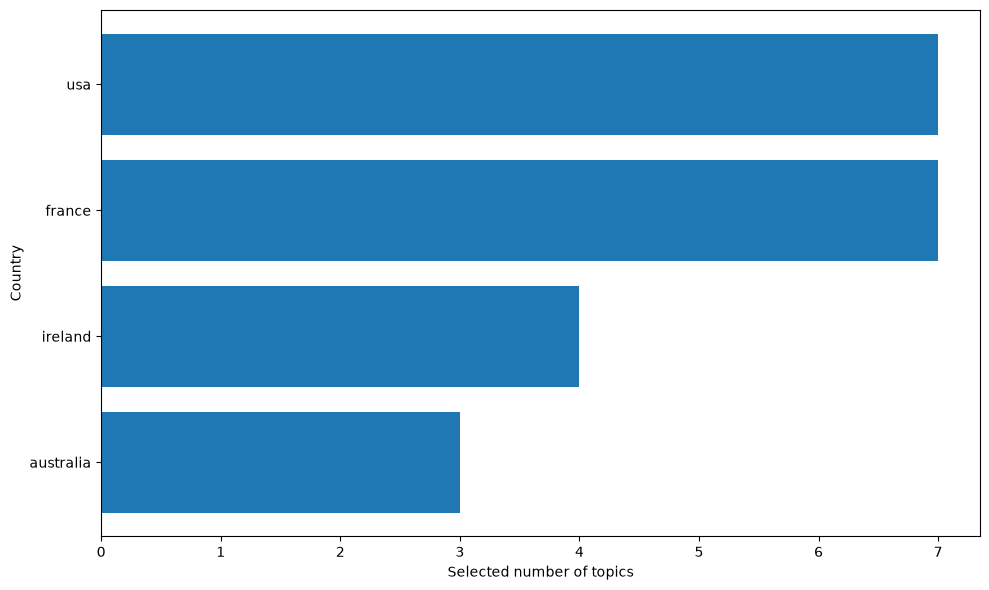

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/per_country/policy_per_country_nmf_selected_topic_counts.png


In [18]:
# ==========================================
# Step 15: Plot per-country selected topic counts
# ==========================================

if "country_model_summary_df" not in globals() or len(country_model_summary_df) == 0:
    print("No per-country models were fitted.")

else:
    country_summary_plot_df = country_model_summary_df.copy()
    country_summary_plot_df = country_summary_plot_df.sort_values(
        "selected_topics",
        ascending=True,
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        country_summary_plot_df["country"],
        country_summary_plot_df["selected_topics"],
    )

    plt.xlabel("Selected number of topics")
    plt.ylabel("Country")
    # plt.title("Policy NMF selected topic count by country")
    plt.tight_layout()

    save_path = COUNTRY_IMG_DIR / "policy_per_country_nmf_selected_topic_counts.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


In [19]:
# ==========================================
# Step 16: Final export summary
# ==========================================

export_summary_rows = [
    {
        "scope": "global",
        "artifact": "topic_number_search",
        "path": str(GLOBAL_OUT_DIR / "policy_global_nmf_topic_number_search.csv"),
    },
    {
        "scope": "global",
        "artifact": "topic_selection_summary",
        "path": str(GLOBAL_OUT_DIR / "policy_global_nmf_topic_selection_summary.csv"),
    },
    {
        "scope": "global",
        "artifact": "topic_info_with_labels",
        "path": str(GLOBAL_OUT_DIR / "policy_global_nmf_topic_info_with_labels_final.csv"),
    },
    {
        "scope": "global",
        "artifact": "documents_with_topic_labels",
        "path": str(GLOBAL_OUT_DIR / "policy_global_nmf_documents_with_topic_labels_final.csv"),
    },
    {
        "scope": "global",
        "artifact": "representative_documents",
        "path": str(GLOBAL_OUT_DIR / "policy_global_nmf_representative_documents.csv"),
    },
    {
        "scope": "global",
        "artifact": "topic_country_distribution",
        "path": str(GLOBAL_OUT_DIR / "policy_global_nmf_topic_country_distribution.csv"),
    },
    {
        "scope": "global",
        "artifact": "topic_selection_plot",
        "path": str(GLOBAL_IMG_DIR / "policy_global_nmf_topic_selection_metrics.png"),
    },
    {
        "scope": "global",
        "artifact": "topic_distribution_plot",
        "path": str(GLOBAL_IMG_DIR / "policy_global_nmf_topic_distribution.png"),
    },
    {
        "scope": "global",
        "artifact": "topic_by_country_plot",
        "path": str(GLOBAL_IMG_DIR / "policy_global_nmf_topic_distribution_by_country.png"),
    },
]

if "country_model_summary_df" in globals() and len(country_model_summary_df) > 0:
    export_summary_rows.append({
        "scope": "per_country",
        "artifact": "country_model_summary",
        "path": str(COUNTRY_OUT_DIR / "policy_country_nmf_model_summary.csv"),
    })

export_summary_df = pd.DataFrame(export_summary_rows)

export_summary_df.to_csv(
    OUT_DIR / "policy_nmf_export_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Policy NMF pipeline exports complete")
print("=" * 80)
display(export_summary_df)


Policy NMF pipeline exports complete


,scope,artifact,path
0,global,topic_number_search,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/global/policy_global_nmf_topic_number_search.csv
1,global,topic_selection_summary,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/global/policy_global_nmf_topic_selection_summary.csv
2,global,topic_info_with_labels,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/global/policy_global_nmf_topic_info_with_labels_final.csv
3,global,documents_with_topic_labels,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/global/policy_global_nmf_documents_with_topic_labels_final.csv
4,global,representative_documents,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/global/policy_global_nmf_representative_documents.csv
5,global,topic_country_distribution,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/global/policy_global_nmf_topic_country_distribution.csv
6,global,topic_selection_plot,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/global/policy_global_nmf_topic_selection_metrics.png
7,global,topic_distribution_plot,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/global/policy_global_nmf_topic_distribution.png
8,global,topic_by_country_plot,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/img/global/policy_global_nmf_topic_distribution_by_country.png
9,per_country,country_model_summary,/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/policy/output/per_country/policy_country_nmf_model_summary.csv
